# Projeto de Análise de Dados Operacionais e Estruturais

## Contexto

Este projeto tem como objetivo explorar e extrair o máximo de insights acionáveis a partir de três bases de dados relacionadas à operação logística:

- Base de clientes
- Classificação econômica (CNAE)
- Base operacional de volumetria de viagens

Apesar da estrutura enxuta (poucas tabelas e colunas), o conjunto de dados permite análises profundas sob diferentes perspectivas: operacional, econômica, temporal, geográfica e estrutural de carteira.



## Objetivos

1. Entender o padrão operacional da empresa:
   - Distribuição temporal (dia, hora)
   - Perfil médio das cargas
   - Estrutura de viagens

2. Identificar concentração estrutural:
   - Concentração por cliente
   - Dependência setorial (CNAE)
   - Possível risco de concentração

3. Mapear padrões comportamentais:
   - Diferença entre grandes clientes e demais
   - Perfil de carga e volume
   - Dinâmica operacional ao longo da semana

4. Gerar insights acionáveis:
   - Riscos de dependência
   - Oportunidades de diversificação
   - Eficiência operacional
   - Estrutura de carteira



## Escopo Analítico

O estudo envolve:

- Análise exploratória estruturada (EDA)
- Segmentação de clientes por relevância volumétrica
- Avaliação de concentração (curva de Pareto)
- Perfil econômico via CNAE
- Padrões temporais de operação
- Comparações entre grupos estratégicos


## Resultado Esperado

Construir um diagnóstico técnico e estratégico da operação, respondendo:

- Onde está a concentração?
- Qual o perfil dominante de operação?
- Existe dependência estrutural relevante?
- Quais são os principais vetores de risco e oportunidade?

O foco central é transformar dados operacionais em inteligência estratégica.

# Dicionário de Dados

## Tabela: cliente

| Campo         | Tipo sugerido | Descrição                                      |
|---------------|--------------|-----------------------------------------------|
| cli_codigo    | INT64        | Identificador único do cliente               |
| cli_fisjur    | STRING(1)    | Tipo de pessoa: F (física) / J (jurídica)    |
| loc_codibge   | INT32        | Código IBGE do município                      |
| loc_descricao | STRING       | Nome do município                             |
| razao         | STRING       | Razão social ou nome do cliente               |
| uf_sigla      | STRING(2)    | UF do cliente                                 |



## Tabela: cliente_cnae

| Campo                | Tipo sugerido        | Descrição                                                      |
|----------------------|----------------------|----------------------------------------------------------------|
| cli_codigo           | INT64                | Identificador do cliente (FK para cliente)                    |
| cnae                 | STRING               | Código CNAE (formato NNNN-N/NN)                               |
| cnae_descr           | STRING               | Descrição do CNAE                                              |
| cne_cnae_principal   | INT8 ou BOOLEAN      | Indicador de CNAE principal (1) ou secundário (0)             |



## Tabela: volumetria

| Campo           | Tipo sugerido  | Descrição                                              |
|----------------|----------------|--------------------------------------------------------|
| cli_codigo      | INT64          | Identificador do cliente (FK para cliente)             |
| dt_viagem       | DATETIME       | Data/hora da viagem                                    |
| m3              | DECIMAL(15,4)  | Cubagem total (m³)                                     |
| perc_descm3     | DECIMAL(5,2)   | Percentual de desconto sobre m³                        |
| peso            | DECIMAL(15,3)  | Peso total (kg)                                        |
| pesom3          | DECIMAL(15,4)  | Peso cubado/tarifário (kg equivalentes)                |
| qtd_ctes        | INT32          | Quantidade de CTEs no registro                         |
| tipopescocubico | STRING(1)      | Tipo de tarifação por peso/cubagem (ex.: M, P)        |
| via_codigo      | INT64          | Identificador da viagem/manifesto                      |
| volumes         | INT32          | Número de volumes                                      |

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Setup + Leitura dos Dados

In [2]:
cliente = pd.read_csv("../data/cliente.csv", sep=";")
cliente_cnae = pd.read_csv("../data/cliente_cnae.csv", sep=";")
volumetria = pd.read_csv("../data/volumetria.csv", sep=";")

cliente.shape, cliente_cnae.shape, volumetria.shape

((131728, 6), (764658, 4), (2654696, 9))

In [3]:
def quick_overview(df: pd.DataFrame, name: str, n: int = 5):
    print(f"=== {name} ===")
    display(df.head(n))
    display(df.sample(min(n, len(df)), random_state=42))
    print("\nDtypes:")
    display(df.dtypes.to_frame("dtype"))
    print("\nMissing (%):")
    display((df.isna().mean() * 100).round(2).to_frame("missing_%").sort_values("missing_%", ascending=False))
    print("\n")

quick_overview(cliente, "cliente")
quick_overview(cliente_cnae, "cliente_cnae")
quick_overview(volumetria, "volumetria")

=== cliente ===


,cli_codigo,razao,cli_fisjur,loc_codibge,loc_descricao,uf_sigla
0,4928843,CLIENTE - 4928843,F,4215000,RIO NEGRINHO,SC
1,1970,CLIENTE - 1970,F,4306809,ENCANTADO,RS
2,2187,CLIENTE - 2187,F,4321501,TORRES,RS
3,2646,CLIENTE - 2646,F,4312625,MULITERNO,RS
4,4670349,CLIENTE - 4670349,F,4114302,MANDIRITUBA,PR


,cli_codigo,razao,cli_fisjur,loc_codibge,loc_descricao,uf_sigla
68351,3594222,CLIENTE - 3594222,J,4209102,JOINVILLE,SC
105385,4121799,CLIENTE - 4121799,J,4200507,AGUAS DE CHAPECO,SC
98160,4054745,CLIENTE - 4054745,J,3525904,JUNDIAI,SP
119848,4377080,CLIENTE - 4377080,J,4204301,CONCORDIA,SC
24147,2785183,CLIENTE - 2785183,J,4310207,IJUI,RS



Dtypes:


,dtype
cli_codigo,int64
razao,str
cli_fisjur,str
loc_codibge,int64
loc_descricao,str
uf_sigla,str


...

,via_codigo,dt_viagem,cli_codigo,tipopesocubico,qtd_ctes,volumes,peso,m3,perc_descm3\tpesom3
1444421,2026-02-19 21:05:33.000,2572780,P,1,2,"1,35",0,0,1.350
1436178,2026-02-11 21:26:20.000,4268215,P,2,3,"7,409",0,0,7.409
1424767,2026-01-30 21:53:12.000,3317381,P,1,1,8,0,0,8.000
1414606,2026-01-21 20:33:16.000,2664068,P,3,3,3,0,0,3.000
1401778,2026-01-08 19:00:19.000,4166901,P,1,1,"0,315",0,0,0.315



Dtypes:


,dtype
via_codigo,str
dt_viagem,int64
cli_codigo,str
tipopesocubico,int64
qtd_ctes,int64
volumes,str
peso,str
m3,str
perc_descm3\tpesom3,float64



Missing (%):


,missing_%
via_codigo,0.0
dt_viagem,0.0
cli_codigo,0.0
tipopesocubico,0.0
qtd_ctes,0.0
volumes,0.0
peso,0.0
m3,0.0
perc_descm3\tpesom3,0.0


In [4]:
# Unicidade esperada do cliente (PK)
cliente_dups = cliente["cli_codigo"].duplicated().sum()
print("cliente cli_codigo duplicados:", cliente_dups)

# Cobertura das FKs
fk_in_cliente_cnae = cliente_cnae["cli_codigo"].isin(cliente["cli_codigo"]).mean()
fk_in_volumetria = volumetria["cli_codigo"].isin(cliente["cli_codigo"]).mean()

print(f"cliente_cnae cli_codigo presentes em cliente: {fk_in_cliente_cnae:.2%}")
print(f"volumetria cli_codigo presentes em cliente: {fk_in_volumetria:.2%}")

# Cardinalidade CNAE por cliente
cnae_per_cliente = cliente_cnae.groupby("cli_codigo").size().describe()
cnae_principal_flag = cliente_cnae["cne_cnae_principal"].value_counts(dropna=False)

display(cnae_per_cliente)
display(cnae_principal_flag)

cliente cli_codigo duplicados: 0
cliente_cnae cli_codigo presentes em cliente: 100.00%
volumetria cli_codigo presentes em cliente: 0.00%


count    117841.000000
mean          6.488896
std           6.663686
min           1.000000
25%           3.000000
50%           5.000000
75%           8.000000
max         137.000000
dtype: float64

cne_cnae_principal
0    640469
1    124189
Name: count, dtype: int64

In [5]:
volumetria.columns.tolist()

['via_codigo',
 'dt_viagem',
 'cli_codigo',
 'tipopesocubico',
 'qtd_ctes',
 'volumes',
 'peso',
 'm3',
 'perc_descm3\tpesom3']

In [6]:
[(c, repr(c)) for c in volumetria.columns]

[('via_codigo', "'via_codigo'"),
 ('dt_viagem', "'dt_viagem'"),
 ('cli_codigo', "'cli_codigo'"),
 ('tipopesocubico', "'tipopesocubico'"),
 ('qtd_ctes', "'qtd_ctes'"),
 ('volumes', "'volumes'"),
 ('peso', "'peso'"),
 ('m3', "'m3'"),
 ('perc_descm3\tpesom3', "'perc_descm3\\tpesom3'")]

In [7]:
volumetria = pd.read_csv(
    "../data/volumetria.csv",
    sep=r"[;\t]",
    engine="python"
)

volumetria.shape, volumetria.columns.tolist()

((2654696, 10),
 ['via_codigo',
  'dt_viagem',
  'cli_codigo',
  'tipopesocubico',
  'qtd_ctes',
  'volumes',
  'peso',
  'm3',
  'perc_descm3',
  'pesom3'])

In [8]:
volumetria.head()

,via_codigo,dt_viagem,cli_codigo,tipopesocubico,qtd_ctes,volumes,peso,m3,perc_descm3,pesom3
0,1395158,2026-01-05 20:32:00.000,3057201,M,1,6,115,"1,12",0,1.120
1,1395158,2026-01-05 20:32:00.000,3412661,P,1,5,"27,38",0,0,27.380
2,1395158,2026-01-05 20:32:00.000,3690638,P,1,9,"30,924",0,0,30.924
3,1395158,2026-01-05 20:32:00.000,4295681,M,1,1,151,"2,61",0,2.610
4,1396958,2026-01-05 07:00:00.000,2553883,P,1,1,"0,001",0,0,0.001


In [9]:
fk_in_volumetria = volumetria["cli_codigo"].isin(cliente["cli_codigo"]).mean()
print(f"volumetria cli_codigo presentes em cliente: {fk_in_volumetria:.2%}")

volumetria cli_codigo presentes em cliente: 100.00%


In [10]:
# Converter apenas vírgula para ponto (sem remover ponto existente)
cols_test = ["m3", "peso", "pesom3"]

for col in cols_test:
    volumetria[col + "_num"] = (
        volumetria[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    volumetria[col + "_num"] = pd.to_numeric(volumetria[col + "_num"], errors="coerce")

tmp = volumetria.loc[volumetria["m3_num"] > 0].copy()
tmp["fator"] = tmp["pesom3_num"] / tmp["m3_num"]

tmp["fator"].describe(percentiles=[.01, .05, .5, .95, .99])

count    5.291630e+05
mean     3.688930e+02
std      1.964455e+04
min      4.347826e-03
1%       8.000000e-01
5%       8.499396e-01
50%      1.000000e+00
95%      8.275862e+02
99%      2.500000e+03
max      7.418000e+06
Name: fator, dtype: float64

In [11]:
# 1) chaves
cliente["cli_codigo"] = pd.to_numeric(cliente["cli_codigo"], errors="coerce").astype("Int64")
volumetria["cli_codigo"] = pd.to_numeric(volumetria["cli_codigo"], errors="coerce").astype("Int64")

# 2) datetime (deixa robusto)
volumetria["dt_viagem"] = pd.to_datetime(volumetria["dt_viagem"], errors="coerce")

# 3) numéricos que podem ter vírgula decimal
num_cols = ["m3", "peso", "pesom3", "volumes", "perc_descm3"]

for col in num_cols:
    if col in volumetria.columns:
        volumetria[col] = (
            volumetria[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )
        volumetria[col] = pd.to_numeric(volumetria[col], errors="coerce")

volumetria.dtypes

via_codigo                 int64
dt_viagem         datetime64[us]
cli_codigo                 Int64
tipopesocubico               str
qtd_ctes                   int64
volumes                    int64
peso                     float64
m3                       float64
perc_descm3              float64
pesom3                   float64
m3_num                   float64
peso_num                 float64
pesom3_num               float64
dtype: object

In [12]:
print("cli_codigo nulos após conversão - cliente:", cliente["cli_codigo"].isna().sum())
print("cli_codigo nulos após conversão - volumetria:", volumetria["cli_codigo"].isna().sum())
print("dt_viagem nulos após parse:", volumetria["dt_viagem"].isna().sum())

cli_codigo nulos após conversão - cliente: 0
cli_codigo nulos após conversão - volumetria: 0
dt_viagem nulos após parse: 0


### Checkpoint 1

#### Ajuste de Parsing e Padronização de Tipos

Agora cheguei em um momento que já conheci melhor os dados disponibilizados, entendendo o tamanho das bases e encontrando logo de início alguns problemas que precisaram ser tratados.

Ao realizar a leitura inicial da base `volumetria`, identifiquei inconsistências estruturais:
- Colunas mescladas devido a separadores mistos (`;` e `\t`);
- Tipos incorretos (datas como inteiro, valores numéricos como string);
- Falha inicial na validação de chave estrangeira com `cliente`.

Reimportei a base utilizando regex como separador (`sep=r"[;\t]"`) e `engine="python"`, garantindo a correta separação das colunas.

Em seguida:
- Padronizei `cli_codigo` como tipo numérico consistente entre as bases;
- Converti `dt_viagem` para datetime;
- Normalizei colunas numéricas que utilizavam vírgula como separador decimal;
- Revalidei integridade referencial, confirmando 100% de correspondência entre `volumetria` e `cliente`.

Essa etapa foi fundamental para assegurar consistência estrutural antes de qualquer análise exploratória ou integração entre as bases.

#### Investigação do Padrão Decimal em `pesom3`

Antes de padronizar as colunas numéricas, investiguei o comportamento da relação entre `pesom3` e `m3` para entender se o ponto presente em valores como `1.120` representava separador decimal ou separador de milhar.

Calculei o fator `pesom3 / m3` para registros com cubagem positiva. A mediana encontrada foi igual a 1.0, com distribuição fortemente assimétrica e cauda longa.

Caso o ponto representasse milhar (ex: 1.120 → 1120), o fator mediano deveria estar próximo de ~1000, o que não ocorreu.

Isso indica que o ponto já representa separador decimal válido na coluna `pesom3`, enquanto outras colunas utilizam vírgula como separador decimal.

Conclusão: a base apresenta inconsistência interna de padrão decimal, e a normalização deve substituir apenas vírgula por ponto, sem remover pontos existentes.

In [13]:
volumetria["dt_viagem"].min(), volumetria["dt_viagem"].max()

(Timestamp('2026-01-01 02:04:24'), Timestamp('2026-02-23 08:16:42'))

In [14]:
volumetria["dt_viagem"].dt.to_period("M").value_counts().sort_index()

dt_viagem
2026-01    1500250
2026-02    1154446
Freq: M, Name: count, dtype: int64

In [15]:
checks = pd.Series({
    "m3 == 0": (volumetria["m3"] == 0).mean(),
    "peso == 0": (volumetria["peso"] == 0).mean(),
    "pesom3 == 0": (volumetria["pesom3"] == 0).mean(),
    "volumes == 0": (volumetria["volumes"] == 0).mean(),
    "qtd_ctes == 0": (volumetria["qtd_ctes"] == 0).mean(),
    "m3 < 0": (volumetria["m3"] < 0).mean(),
    "peso < 0": (volumetria["peso"] < 0).mean(),
    "pesom3 < 0": (volumetria["pesom3"] < 0).mean(),
    "perc_descm3 < 0": (volumetria["perc_descm3"] < 0).mean(),
    "perc_descm3 > 100": (volumetria["perc_descm3"] > 100).mean(),
}).sort_values(ascending=False)

checks

m3 == 0              0.800669
perc_descm3 > 100    0.000521
peso == 0            0.000000
pesom3 == 0          0.000000
qtd_ctes == 0        0.000000
volumes == 0         0.000000
m3 < 0               0.000000
peso < 0             0.000000
pesom3 < 0           0.000000
perc_descm3 < 0      0.000000
dtype: float64

In [16]:
volumetria[["m3", "peso", "pesom3", "perc_descm3", "qtd_ctes", "volumes"]].describe(
    percentiles=[.01, .05, .5, .95, .99]
).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
m3,2654696.0,0.151415,2.046749,0.0000,0.00,0.000,0.00,0.744,2.91000,3030.6276
peso,2654696.0,84.996187,274.290671,0.0010,0.12,0.800,17.00,355.000,1144.52935,16495.3750
pesom3,2654696.0,70.412187,259.597633,0.0001,0.04,0.277,10.36,295.000,1044.20200,16495.3750
perc_descm3,2654696.0,0.787098,6.881965,0.0000,0.00,0.000,0.00,0.000,20.00000,1590.0000
qtd_ctes,2654696.0,1.384034,1.907043,1.0000,1.00,1.000,1.00,3.000,7.00000,171.0000
volumes,2654696.0,6.547555,25.745101,1.0000,1.00,1.000,2.00,23.000,81.00000,4575.0000


In [17]:
volumetria.groupby("tipopesocubico")[["peso", "pesom3", "m3"]].agg(["count", "mean", "median"]).round(3)

peso                   pesom3                       m3  \
                  count     mean median    count    mean  median    count   
tipopesocubico                                                              
M                288294  135.345  56.54   288294   1.051   0.516   288294   
P               2366402   78.862  15.00  2366402  78.862  15.000  2366402   

                              
                 mean median  
tipopesocubico                
M               1.117  0.545  
P               0.034  0.000

In [18]:
print((volumetria["pesom3"] >= volumetria["peso"]).mean().round(2))

0.89


In [19]:
cnae_principal_por_cliente = (
    cliente_cnae.assign(is_principal=cliente_cnae["cne_cnae_principal"].astype(int))
    .groupby("cli_codigo")["is_principal"]
    .sum()
)

(cnae_principal_por_cliente.value_counts().sort_index(), (cnae_principal_por_cliente == 1).mean())

(is_principal
 0        11
 1    111675
 2      5957
 3       193
 4         4
 5         1
 Name: count, dtype: int64,
 np.float64(0.9476752573382778))

### Checkpoint 2

#### Entendimento Temporal e Checagens de Consistência (Volumetria + CNAE)

Após estabilizar a leitura e tipagem das bases, avaliei a janela temporal e a consistência de domínio dos principais campos da `volumetria`.

A base cobre o período de **01/01/2026 a 23/02/2026**, com registros concentrados em **janeiro e fevereiro** e **53 dias distintos**. Isso limita análises de sazonalidade anual, mas permite comparações mensais e variações diárias/semanais.

Nas checagens de consistência, observei que:
- **80%** dos registros possuem `m3 == 0`, sugerindo que grande parte das operações é tarifada por peso ou que a cubagem não é informada em muitos casos;
- Não há valores negativos e praticamente não há zeros em `peso`, `pesom3`, `qtd_ctes` e `volumes`;
- Existem casos raros de `perc_descm3 > 100`, além de outliers relevantes em `m3`, `volumes` e `qtd_ctes`, que serão tratados com cautela (via flags e/ou cortes robustos) para não distorcer estatísticas e visualizações.

Também validei a consistência do indicador de CNAE principal. A maior parte dos clientes (~95%) possui **exatamente 1 CNAE principal**, mas há uma fração minoritária com 0 ou múltiplos principais, o que exigirá uma regra determinística para construir uma dimensão de CNAE sem duplicar linhas na integração.

# Análise Exploratória (EDA)

## Padrões Temporais

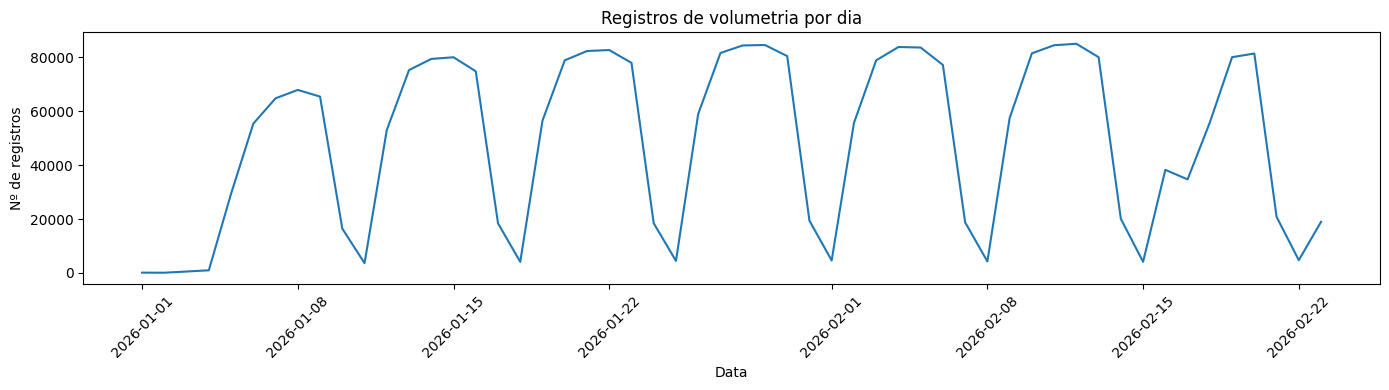

count       53.000000
mean     50088.603774
std      31858.516822
min         65.000000
25%      18766.000000
50%      57442.000000
75%      80079.000000
max      85054.000000
dtype: float64

In [20]:
daily_counts = (
    volumetria
    .groupby(volumetria["dt_viagem"].dt.date)
    .size()
    .sort_index()
)

plt.figure(figsize=(14, 4))
plt.plot(daily_counts.index, daily_counts.values)
plt.title("Registros de volumetria por dia")
plt.xlabel("Data")
plt.ylabel("Nº de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

daily_counts.describe()

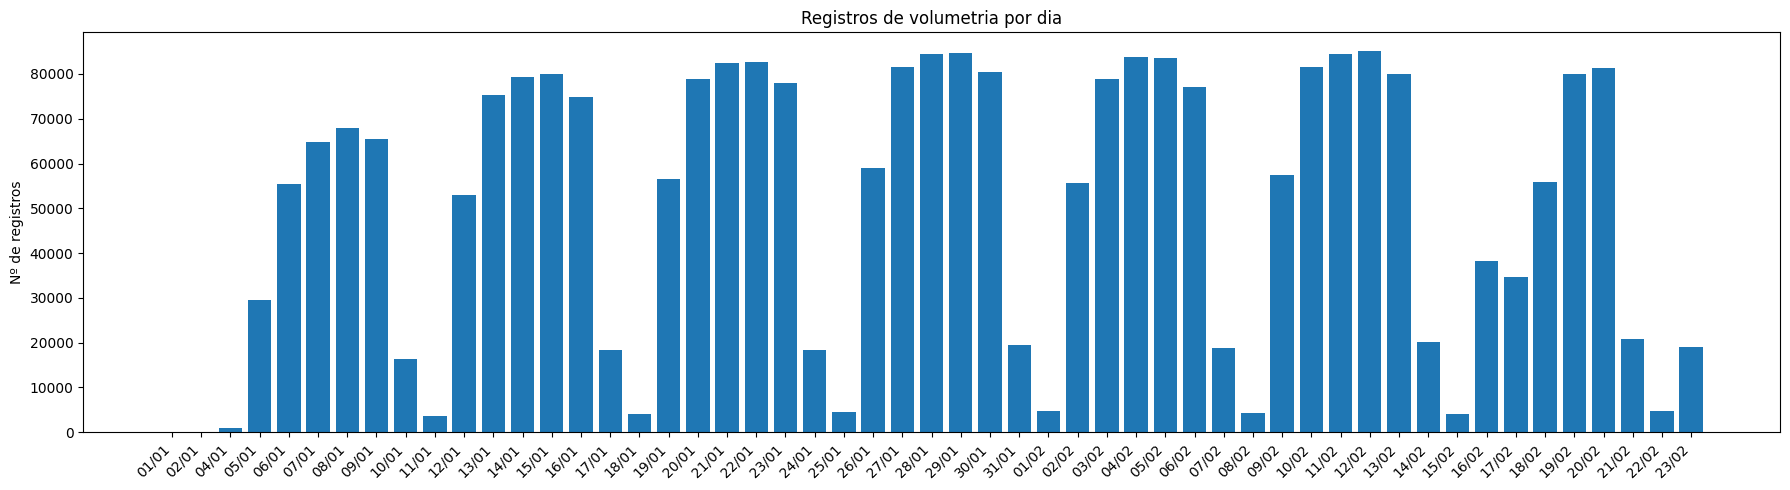

In [21]:
daily_counts = (
    volumetria
    .groupby(volumetria["dt_viagem"].dt.date)
    .size()
    .sort_index()
)

# Labels dd/mm
x_labels = [d.strftime("%d/%m") for d in daily_counts.index]

plt.figure(figsize=(18, 5))
plt.bar(range(len(daily_counts)), daily_counts.values)
plt.title("Registros de volumetria por dia")
plt.xlabel("")
plt.ylabel("Nº de registros")

step = 1
plt.xticks(
    ticks=list(range(0, len(x_labels), step)),
    labels=[x_labels[i] for i in range(0, len(x_labels), step)],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [22]:
daily_df = daily_counts.reset_index()
daily_df.columns = ["date", "n_registros"]
daily_df["date"] = pd.to_datetime(daily_df["date"])
daily_df["dow"] = daily_df["date"].dt.day_name()

dow_stats = (
    daily_df.groupby("dow")["n_registros"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

dow_stats

,count,mean,median
dow,,,
Wednesday,7,76463.428571,82357.0
Thursday,8,70522.875000,81406.0
Tuesday,7,69481.857143,78895.0
Friday,8,67191.750000,77589.0
Monday,8,46031.875000,54322.0
Saturday,7,18903.571429,18766.0
Sunday,8,3847.750000,4170.5


In [23]:
# Mapeamento manual
dow_map = {
    "Monday": "Segunda",
    "Tuesday": "Terça",
    "Wednesday": "Quarta",
    "Thursday": "Quinta",
    "Friday": "Sexta",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

daily_df["dow_pt"] = daily_df["dow"].map(dow_map)

order_pt = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]

dow_stats_pt = (
    daily_df.groupby("dow_pt")["n_registros"]
    .agg(["count", "mean", "median"])
    .reindex(order_pt)
)

dow_stats_pt

,count,mean,median
dow_pt,,,
Segunda,8,46031.875000,54322.0
Terça,7,69481.857143,78895.0
Quarta,7,76463.428571,82357.0
Quinta,8,70522.875000,81406.0
Sexta,8,67191.750000,77589.0
Sábado,7,18903.571429,18766.0
Domingo,8,3847.750000,4170.5


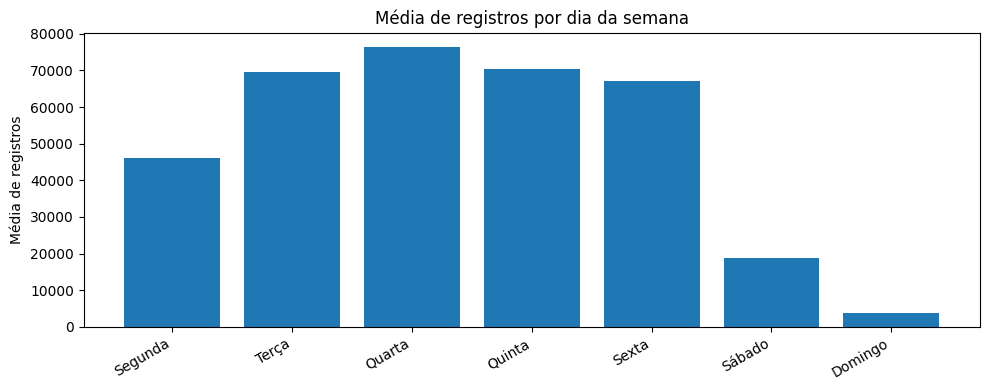

In [24]:
dow_mean_pt = daily_df.groupby("dow_pt")["n_registros"].mean().reindex(order_pt)

plt.figure(figsize=(10, 4))
plt.bar(dow_mean_pt.index, dow_mean_pt.values)
plt.title("Média de registros por dia da semana")
plt.xlabel("")
plt.ylabel("Média de registros")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [25]:
volumetria["hora"] = volumetria["dt_viagem"].dt.hour

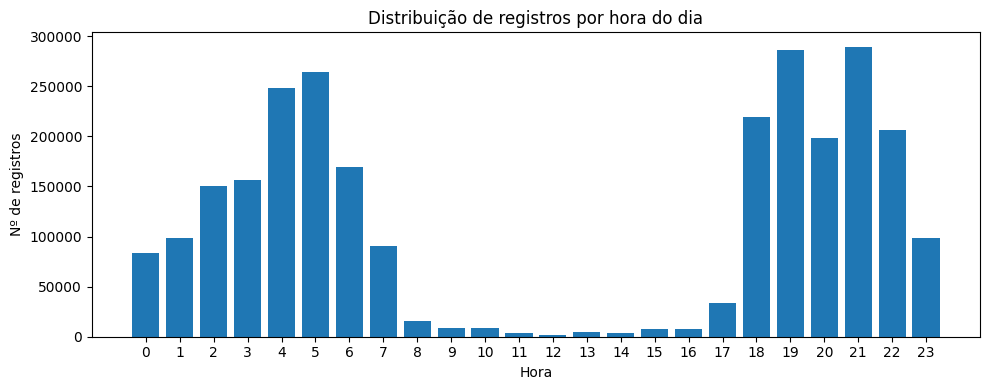

count        24.000000
mean     110612.333333
std      103179.730595
min        1564.000000
25%        8632.250000
50%       94378.000000
75%      199875.000000
max      289290.000000
Name: count, dtype: float64

In [26]:
hour_counts = volumetria["hora"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(hour_counts.index, hour_counts.values)
plt.title("Distribuição de registros por hora do dia")
plt.xlabel("Hora")
plt.ylabel("Nº de registros")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

hour_counts.describe()

In [27]:
# Garantir coluna hora
volumetria["hora"] = volumetria["dt_viagem"].dt.hour
volumetria["dow_en"] = volumetria["dt_viagem"].dt.day_name()

# Mapeamento para PT-BR
dow_map = {
    "Monday": "Segunda",
    "Tuesday": "Terça",
    "Wednesday": "Quarta",
    "Thursday": "Quinta",
    "Friday": "Sexta",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

volumetria["dow"] = volumetria["dow_en"].map(dow_map)

ordem_semana = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]

heatmap_data = (
    volumetria
    .groupby(["dow", "hora"])
    .size()
    .unstack(fill_value=0)
    .reindex(ordem_semana)
)

heatmap_data

hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dow,,,,,,,,,,,,,,,,,,,,,
Segunda,6596,15272,19240,17079,25562,14262,17923,12933,987,580,...,330,563,1262,5924,39043,50203,33058,51202,36768,17696
Terça,14379,16224,26156,29138,45774,48528,27453,15500,3105,1594,...,437,1055,1373,6068,40395,54598,36984,54286,39378,20417
Quarta,16766,17747,28051,30124,48304,52437,30784,17365,3183,2102,...,380,918,1074,6379,44690,62256,42096,63285,43534,20851
Quinta,17794,19906,33376,32348,50858,60148,33454,18823,3666,1708,...,418,1044,1288,6289,46373,62629,42065,61340,45568,21870
Sexta,16950,21348,32602,32808,55328,56264,34993,19826,3500,2269,...,547,891,1200,6697,47431,55645,42151,55099,35269,13342
Sábado,11186,8418,10894,14504,21840,32701,24509,5677,1390,817,...,189,8,0,7,0,0,0,0,0,0
Domingo,13,0,68,0,58,0,0,8,0,47,...,1827,2942,1461,2054,1727,767,1479,4078,5484,4448


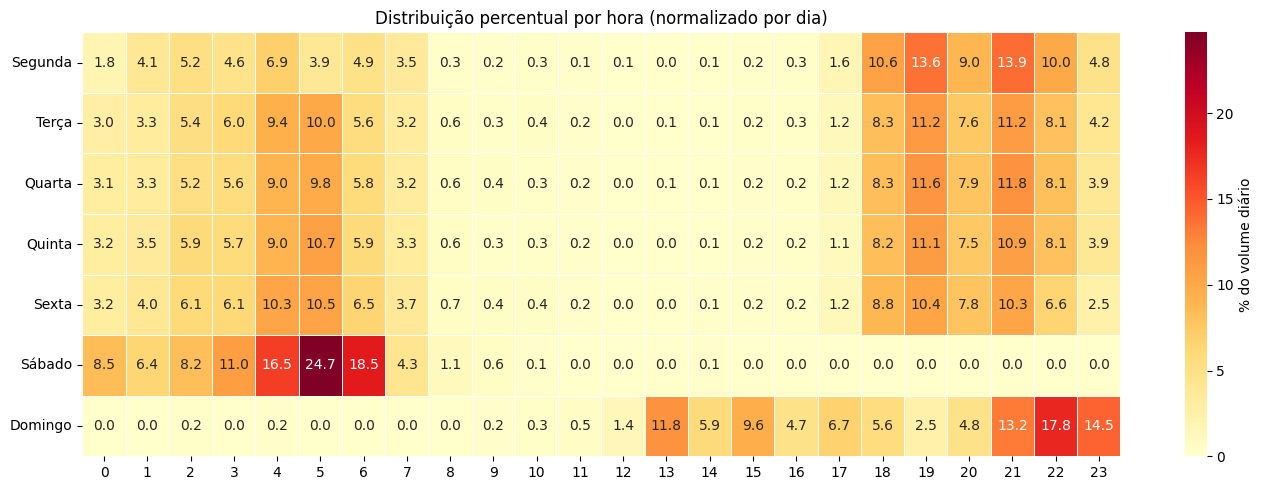

In [28]:
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 5))

sns.heatmap(
    heatmap_pct,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "% do volume diário"}
)

plt.title("Distribuição percentual por hora (normalizado por dia)")
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Checkpoint 3

A análise por dia da semana evidenciou um padrão operacional consistente: 
- picos de movimentação entre **terça e quinta**, com destaque para quarta;
- redução significativa aos finais de semana, especialmente aos domingos.

Esse comportamento sugere forte concentração das operações em dias úteis, com baixa atividade no fim de semana, possivelmente refletindo a dinâmica logística da empresa.

Além do padrão semanal, a análise por hora do dia revelou uma distribuição claramente estruturada ao longo do ciclo diário.

Observa-se um comportamento **bimodal** nos dias úteis:
- concentração relevante de registros na **madrugada/início da manhã (aprox. 2h–6h)**;
- novo pico no **período da noite (aprox. 18h–22h)**;
- volume significativamente reduzido entre o fim da manhã e o início da tarde.

Nos finais de semana, o comportamento é distinto:
- no **sábado**, há forte concentração na madrugada (principalmente entre 4h–6h) e queda acentuada ao longo do dia;
- no **domingo**, a operação é bastante reduzida durante quase todo o dia, com aumento pontual no período da noite.

Esse padrão sugere janelas operacionais bem definidas, possivelmente relacionadas a consolidação de cargas, programação de embarques ou rotinas logísticas estruturadas em turnos específicos.

## Concentração por Cliente

In [29]:
cliente_volume = (
    volumetria
    .groupby("cli_codigo")
    .agg(
        total_pesom3=("pesom3", "sum"),
        total_peso=("peso", "sum"),
        total_m3=("m3", "sum"),
        total_ctes=("qtd_ctes", "sum"),
        total_registros=("pesom3", "count")
    )
    .sort_values("total_pesom3", ascending=False)
)

cliente_volume.head()

,total_pesom3,total_peso,total_m3,total_ctes,total_registros
cli_codigo,,,,,
4228148,1.354973e+06,1354972.887,0.2468,5227,2082
2759536,1.338923e+06,1338923.233,0.0000,3649,1319
4226575,1.302794e+06,1309385.219,63.2010,3774,1661
2674191,1.227777e+06,1242371.922,94.4298,3061,1137
4159665,1.147559e+06,1150007.395,15.5112,1056,609


In [30]:
cliente_volume["pct_acumulado"] = (
    cliente_volume["total_pesom3"].cumsum() /
    cliente_volume["total_pesom3"].sum()
)

cliente_volume["pct_cliente_acumulado"] = (
    range(1, len(cliente_volume)+1)
)

cliente_volume["pct_cliente_acumulado"] /= len(cliente_volume)

cliente_volume.head()

,total_pesom3,total_peso,total_m3,total_ctes,total_registros,pct_acumulado,pct_cliente_acumulado
cli_codigo,,,,,,,
4228148,1.354973e+06,1354972.887,0.2468,5227,2082,0.007249,0.000008
2759536,1.338923e+06,1338923.233,0.0000,3649,1319,0.014412,0.000015
4226575,1.302794e+06,1309385.219,63.2010,3774,1661,0.021381,0.000023
2674191,1.227777e+06,1242371.922,94.4298,3061,1137,0.027950,0.000030
4159665,1.147559e+06,1150007.395,15.5112,1056,609,0.034089,0.000038


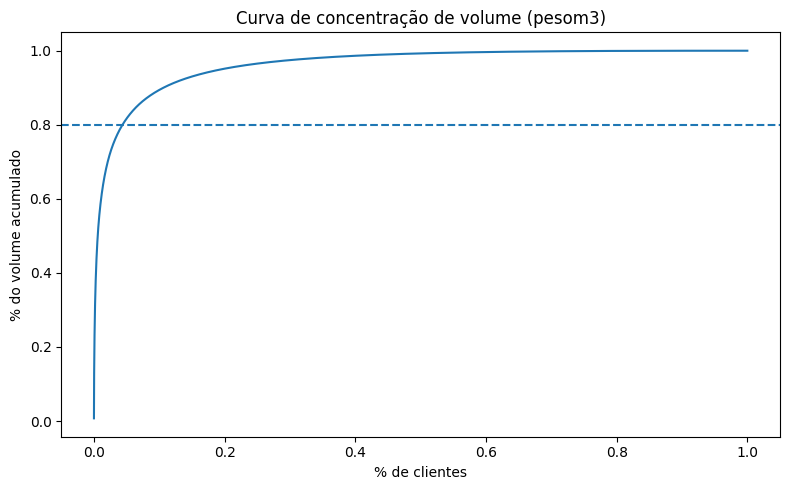

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(
    cliente_volume["pct_cliente_acumulado"],
    cliente_volume["pct_acumulado"]
)

plt.axhline(0.8, linestyle="--")
plt.title("Curva de concentração de volume (pesom3)")
plt.xlabel("% de clientes")
plt.ylabel("% do volume acumulado")
plt.tight_layout()
plt.show()

In [32]:
# % de clientes que geram 80% do volume
clientes_80 = (
    cliente_volume[cliente_volume["pct_acumulado"] <= 0.8]
    .shape[0]
)

clientes_80_pct = clientes_80 / len(cliente_volume)

clientes_80, clientes_80_pct

(5755, 0.043688509656261386)

### Checkpoint 4

#### Concentração de Volume por Cliente

A análise da distribuição de `pesom3` por cliente evidenciou forte concentração do volume operacional.

A curva de concentração (tipo Pareto) mostrou que aproximadamente **4% dos clientes são responsáveis por 80% do volume tarifário total** no período analisado.

Esse resultado indica uma dependência significativa de uma parcela reduzida da base de clientes, caracterizando uma estrutura altamente concentrada.

Do ponto de vista de negócio, esse padrão pode representar:
- risco de concentração de receita;
- necessidade de gestão estratégica dos principais clientes;
- potencial de crescimento via expansão da base intermediária.

In [33]:
limite_80 = cliente_volume.loc[cliente_volume["pct_acumulado"] <= 0.8].index

volumetria["grupo_cliente"] = np.where(
    volumetria["cli_codigo"].isin(limite_80),
    "Top 4%",
    "Demais 96%"
)

In [34]:
volumetria.groupby("grupo_cliente")["pesom3"].sum() / volumetria["pesom3"].sum()

grupo_cliente
Demais 96%    0.20002
Top 4%        0.79998
Name: pesom3, dtype: float64

In [35]:
hour_group = (
    volumetria
    .groupby(["grupo_cliente", "hora"])
    .size()
    .unstack(fill_value=0)
)

hour_group_pct = hour_group.div(hour_group.sum(axis=1), axis=0) * 100

hour_group_pct

hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
grupo_cliente,,,,,,,,,,,,,,,,,,,,,
Demais 96%,2.931837,3.581246,5.197887,5.516273,8.699148,8.995015,5.552630,2.895904,0.516125,0.289725,...,0.139003,0.268263,0.297772,1.486603,9.774320,12.499806,7.488503,11.678637,7.911866,3.598401
Top 4%,3.404519,3.891686,6.199270,6.288433,10.055016,11.058507,7.306058,3.966393,0.688108,0.404869,...,0.174369,0.292446,0.277828,0.998241,6.558346,8.806165,7.410647,10.003408,7.585985,3.848558


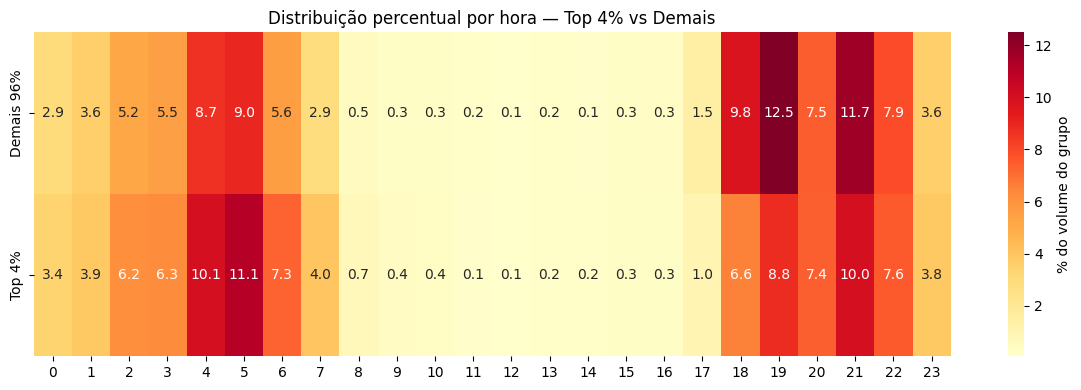

In [36]:
plt.figure(figsize=(12, 4))

sns.heatmap(
    hour_group_pct,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "% do volume do grupo"}
)

plt.title("Distribuição percentual por hora — Top 4% vs Demais")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [37]:
tarifacao_group = (
    volumetria
    .groupby(["grupo_cliente", "tipopesocubico"])
    .size()
    .unstack(fill_value=0)
)

tarifacao_group_pct = tarifacao_group.div(tarifacao_group.sum(axis=1), axis=0) * 100

tarifacao_group_pct

tipopesocubico,M,P
grupo_cliente,,
Demais 96%,9.713325,90.286675
Top 4%,12.171352,87.828648


In [38]:
perfil_group = (
    volumetria
    .groupby("grupo_cliente")
    .agg(
        peso_medio=("peso", "mean"),
        pesom3_medio=("pesom3", "mean"),
        m3_medio=("m3", "mean"),
        ctes_medio=("qtd_ctes", "mean"),
        volumes_medio=("volumes", "mean")
    )
)

perfil_group

,peso_medio,pesom3_medio,m3_medio,ctes_medio,volumes_medio
grupo_cliente,,,,,
Demais 96%,35.371519,26.394523,0.097762,1.123318,2.937430
Top 4%,141.768506,120.769901,0.212797,1.682303,10.677662


### Checkpoint 5

#### Comparação Operacional — Top 4% vs Demais Clientes

Ao segmentar a base entre os clientes responsáveis por 80% do volume (Top 4%) e os demais 96%, observei que o padrão temporal é relativamente semelhante entre os grupos, com estrutura bimodal ao longo do dia.

A principal diferença está no perfil operacional:

- O **peso médio por registro** dos Top 4% é aproximadamente 4 vezes maior;
- O **peso tarifário médio (pesom3)** é cerca de 4,5 vezes superior;
- O **número médio de volumes por registro** é mais de 3 vezes maior;
- Há leve aumento na média de CTEs por registro.

Isso indica que a concentração de volume não decorre de maior frequência operacional, mas sim de **cargas significativamente maiores por operação**.

Em termos práticos, os principais clientes operam com embarques mais robustos e maior densidade logística por registro.

In [39]:
# Ordenar para garantir critério determinístico
cliente_cnae_sorted = cliente_cnae.sort_values(["cli_codigo", "cne_cnae_principal", "cnae"], ascending=[True, False, True])

# Manter apenas um CNAE por cliente (o primeiro após ordenação)
cnae_principal = (
    cliente_cnae_sorted
    .drop_duplicates(subset=["cli_codigo"])
    [["cli_codigo", "cnae", "cnae_descr"]]
)

cnae_principal.head()

,cli_codigo,cnae,cnae_descr
0,72613,7120-1/00,Testes e análises técnicas
3,281372,1340-5/01,"Estamparia e texturização em fios, tecidos, ar..."
6,843640,7739-0/99,Aluguel de outras máquinas e equipamentos come...
12,1176388,1622-6/02,Fabricação de esquadrias de madeira e de peças...
14,1258567,4641-9/01,Comércio atacadista de tecidos


In [40]:
cliente_enriquecido = (
    cliente
    .merge(cnae_principal, on="cli_codigo", how="left")
)

cliente_enriquecido.head()

,cli_codigo,razao,cli_fisjur,loc_codibge,loc_descricao,uf_sigla,cnae,cnae_descr
0,4928843,CLIENTE - 4928843,F,4215000,RIO NEGRINHO,SC,NaN,NaN
1,1970,CLIENTE - 1970,F,4306809,ENCANTADO,RS,NaN,NaN
2,2187,CLIENTE - 2187,F,4321501,TORRES,RS,NaN,NaN
3,2646,CLIENTE - 2646,F,4312625,MULITERNO,RS,NaN,NaN
4,4670349,CLIENTE - 4670349,F,4114302,MANDIRITUBA,PR,NaN,NaN


In [41]:
volumetria_enriquecida = (
    volumetria
    .merge(
        cliente_enriquecido[["cli_codigo", "cnae", "cnae_descr"]],
        on="cli_codigo",
        how="left"
    )
)

volumetria_enriquecida.head()

,via_codigo,dt_viagem,cli_codigo,tipopesocubico,qtd_ctes,volumes,peso,m3,perc_descm3,pesom3,m3_num,peso_num,pesom3_num,hora,dow_en,dow,grupo_cliente,cnae,cnae_descr
0,1395158,2026-01-05 20:32:00,3057201,M,1,6,115.000,1.12,0.0,1.120,1.12,115.000,1.120,20,Monday,Segunda,Demais 96%,4773-3/00,Comércio varejista de artigos médicos e ortopé...
1,1395158,2026-01-05 20:32:00,3412661,P,1,5,27.380,0.00,0.0,27.380,0.00,27.380,27.380,20,Monday,Segunda,Top 4%,4530-7/01,Comércio por atacado de peças e acessórios nov...
2,1395158,2026-01-05 20:32:00,3690638,P,1,9,30.924,0.00,0.0,30.924,0.00,30.924,30.924,20,Monday,Segunda,Demais 96%,2063-1/00,"Fabricação de cosméticos, produtos de perfumar..."
3,1395158,2026-01-05 20:32:00,4295681,M,1,1,151.000,2.61,0.0,2.610,2.61,151.000,2.610,20,Monday,Segunda,Top 4%,4665-6/00,Comércio atacadista de máquinas e equipamentos...
4,1396958,2026-01-05 07:00:00,2553883,P,1,1,0.001,0.00,0.0,0.001,0.00,0.001,0.001,7,Monday,Segunda,Top 4%,4511-1/01,"Comércio a varejo de automóveis, camionetas e ..."


In [42]:
cnae_volume = (
    volumetria_enriquecida
    .groupby("cnae_descr")
    .agg(total_pesom3=("pesom3", "sum"))
    .sort_values("total_pesom3", ascending=False)
)

cnae_volume.head(10)

,total_pesom3
cnae_descr,
Comércio por atacado de peças e acessórios novos para veículos automotores,7.087662e+06
Fabricação de embalagens de material plástico,7.078740e+06
Comércio atacadista de ferragens e ferramentas,5.078425e+06
"Fabricação de máquinas e equipamentos para a agricultura e pecuária, peças e acessórios, exceto para irrigação",4.935998e+06
Fabricação de tecidos de malha,4.237483e+06
"Confecção de peças do vestuário, exceto roupas íntimas e as confeccionadas sob medida",4.002105e+06
"Comércio atacadista de máquinas, aparelhos e equipamentos para uso agropecuário; partes e peças",3.710130e+06
Fabricação de outros produtos alimentícios não especificados anteriormente,3.333640e+06
Comércio a varejo de peças e acessórios novos para veículos automotores,3.332018e+06


In [43]:
cnae_group = (
    volumetria_enriquecida
    .groupby(["grupo_cliente", "cnae_descr"], as_index=False)
    .agg(total_pesom3=("pesom3", "sum"))
)

cnae_group["pct_volume_grupo"] = (
    cnae_group["total_pesom3"] /
    cnae_group.groupby("grupo_cliente")["total_pesom3"].transform("sum")
)

cnae_group.head(20)

,grupo_cliente,cnae_descr,total_pesom3,pct_volume_grupo
0,Demais 96%,Abate de aves,36848.0484,1.014601e-03
1,Demais 96%,Abate de pequenos animais,815.7500,2.246144e-05
2,Demais 96%,Acabamento de calçados de couro sob contrato,5661.2910,1.558820e-04
3,Demais 96%,Administração de consórcios para aquisição de ...,210.3800,5.792753e-06
4,Demais 96%,Administração de obras,1653.5420,4.552981e-05
5,Demais 96%,Administração pública em geral,4844.5138,1.333923e-04
6,Demais 96%,"Agenciamento de cargas, exceto para o transpor...",2923.1400,8.048783e-05
7,Demais 96%,"Agenciamento de espaços para publicidade, exce...",11244.1180,3.096036e-04
8,Demais 96%,Agências de publicidade,4293.6436,1.182243e-04
9,Demais 96%,Agências de viagens,2692.6560,7.414152e-05


In [44]:
top_cnae_top4 = (
    volumetria_enriquecida
    .query('grupo_cliente == "Top 4%"')
    .groupby("cnae_descr", as_index=False)
    .agg(total_pesom3=("pesom3", "sum"))
    .sort_values("total_pesom3", ascending=False)
)

top_cnae_top4["pct_top4"] = (
    top_cnae_top4["total_pesom3"] /
    top_cnae_top4["total_pesom3"].sum()
)

top_cnae_top4.assign(pct_top4=lambda df: df["pct_top4"] * 100)[["cnae_descr", "total_pesom3", "pct_top4"]].head(10)

,cnae_descr,total_pesom3,pct_top4
287,Fabricação de embalagens de material plástico,6.790688e+06,4.543846
120,Comércio por atacado de peças e acessórios nov...,6.225889e+06,4.165923
66,Comércio atacadista de ferragens e ferramentas,4.884713e+06,3.268503
336,Fabricação de máquinas e equipamentos para a a...,4.315917e+06,2.887905
408,Fabricação de tecidos de malha,4.173253e+06,2.792445
362,Fabricação de outros produtos alimentícios não...,3.182982e+06,2.129826
170,"Confecção de peças do vestuário, exceto roupas...",2.775745e+06,1.857332
86,"Comércio atacadista de máquinas, aparelhos e e...",2.753470e+06,1.842427
387,"Fabricação de produtos de papel, cartolina, pa...",2.719227e+06,1.819513
43,Comércio atacadista de artigos de escritório e...,2.410650e+06,1.613036


In [45]:
top_cnae_top4["pct_top4"] = top_cnae_top4["pct_top4"].astype(float)

top_cnae_top4["pct_top4_acum"] = top_cnae_top4["pct_top4"].cumsum()

top_cnae_top4.loc[:9, ["cnae_descr", "pct_top4", "pct_top4_acum"]].assign(
    pct_top4=lambda df: df["pct_top4"] * 100,
    pct_top4_acum=lambda df: df["pct_top4_acum"] * 100
)

,cnae_descr,pct_top4,pct_top4_acum
287,Fabricação de embalagens de material plástico,4.543846,4.543846
120,Comércio por atacado de peças e acessórios nov...,4.165923,8.709768
66,Comércio atacadista de ferragens e ferramentas,3.268503,11.978271
336,Fabricação de máquinas e equipamentos para a a...,2.887905,14.866176
408,Fabricação de tecidos de malha,2.792445,17.658621
...,...,...,...
231,Fabricação de artefatos de cimento para uso na...,0.008902,99.342843
441,"Lojas de variedades, exceto lojas de departame...",0.008848,99.351692
196,Edição integrada à impressão de jornais diários,0.008747,99.360438
175,Construção de barragens e represas para geraçã...,0.008701,99.369139


In [46]:
for thr in [0.25, 0.5, 0.8]:
    n = (top_cnae_top4["pct_top4_acum"] <= thr).sum()
    print(f"CNAEs necessários para atingir {int(thr*100)}% do volume do Top 4%: {n}")

CNAEs necessários para atingir 25% do volume do Top 4%: 8
CNAEs necessários para atingir 50% do volume do Top 4%: 30
CNAEs necessários para atingir 80% do volume do Top 4%: 97


In [47]:
cnae_group_ranked = (
    cnae_group
    .sort_values(["grupo_cliente", "pct_volume_grupo"], ascending=[True, False])
    .groupby("grupo_cliente")
    .head(10)
    .copy()
)

cnae_group_ranked["pct_volume_grupo"] *= 100

cnae_group_ranked[["grupo_cliente", "cnae_descr", "total_pesom3", "pct_volume_grupo"]]

,grupo_cliente,cnae_descr,total_pesom3,pct_volume_grupo
135,Demais 96%,Comércio a varejo de peças e acessórios novos ...,1.921882e+06,5.291846
323,Demais 96%,"Confecção de peças do vestuário, exceto roupas...",1.226360e+06,3.376746
303,Demais 96%,Comércio varejista de outros produtos não espe...,9.949846e+05,2.739662
204,Demais 96%,"Comércio atacadista de máquinas, aparelhos e e...",9.566596e+05,2.634135
247,Demais 96%,Comércio por atacado de peças e acessórios nov...,8.617735e+05,2.372869
281,Demais 96%,Comércio varejista de ferragens e ferramentas,7.111911e+05,1.958244
627,Demais 96%,Fabricação de móveis com predominância de madeira,6.469689e+05,1.781410
614,Demais 96%,Fabricação de máquinas e equipamentos para a a...,6.200814e+05,1.707376
203,Demais 96%,Comércio atacadista de máquinas e equipamentos...,5.819919e+05,1.602498
265,Demais 96%,Comércio varejista de artigos do vestuário e a...,5.363242e+05,1.476753


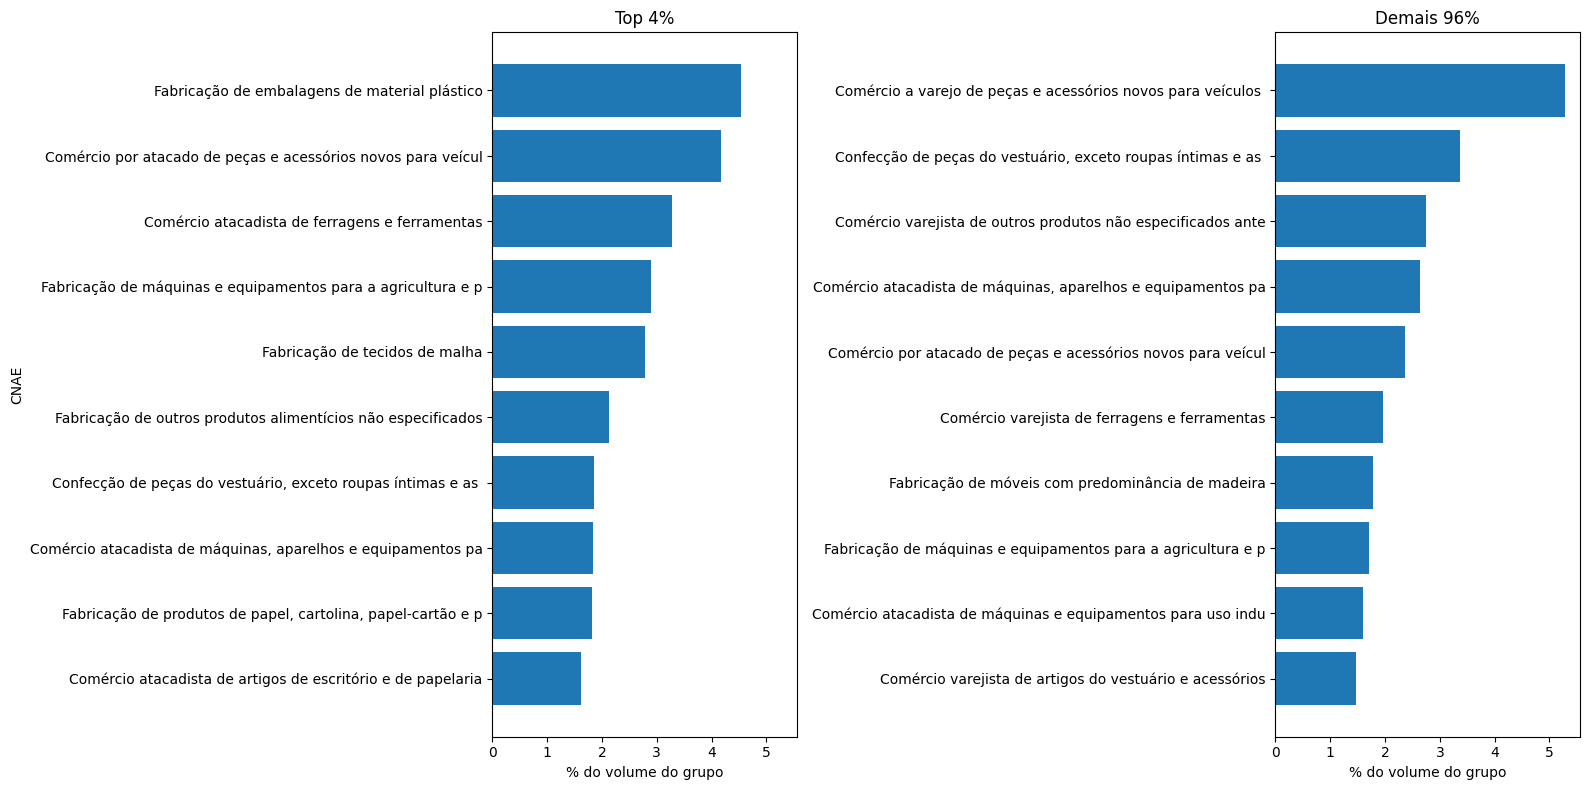

In [48]:
# Preparar dados ordenados
cnae_group_ranked = (
    cnae_group
    .sort_values(["grupo_cliente", "pct_volume_grupo"], ascending=[True, False])
    .groupby("grupo_cliente")
    .head(10)
    .copy()
)

cnae_group_ranked["pct_volume_grupo"] *= 100

# Separar grupos
df_top = cnae_group_ranked[cnae_group_ranked["grupo_cliente"] == "Top 4%"] \
    .sort_values("pct_volume_grupo")

df_demais = cnae_group_ranked[cnae_group_ranked["grupo_cliente"] == "Demais 96%"] \
    .sort_values("pct_volume_grupo")

# Criar subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

# Plot Top 4%
axes[0].barh(df_top["cnae_descr"].str.slice(0, 60), df_top["pct_volume_grupo"])
axes[0].set_title("Top 4%")
axes[0].set_xlabel("% do volume do grupo")
axes[0].set_ylabel("CNAE")

# Plot Demais 96%
axes[1].barh(df_demais["cnae_descr"].str.slice(0, 60), df_demais["pct_volume_grupo"])
axes[1].set_title("Demais 96%")
axes[1].set_xlabel("% do volume do grupo")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Checkpoint 6

#### Perfil Econômico (CNAE) da Concentração de Volume

Após segmentar os clientes em dois grupos — Top 4% (responsáveis por aproximadamente 80% do volume total) e Demais 96% — integrei o CNAE principal à base de volumetria com o objetivo de avaliar se a concentração identificada anteriormente poderia ser explicada por dependência setorial.

#### Concentração setorial dentro do Top 4%

Ao ordenar os CNAEs por participação no volume do grupo Top 4%, observei que:

- O CNAE líder representa cerca de 4,5% do volume do grupo.
- Os dois principais setores somam aproximadamente 9%.
- São necessários 8 CNAEs para atingir 25% do volume.
- São necessários 30 CNAEs para atingir 50% do volume.
- Para alcançar 80% do volume, são necessários 97 CNAEs distintos.

Esse resultado indica que, embora exista forte concentração por cliente, não há concentração relevante em um único setor econômico. O volume do grupo Top 4% está distribuído entre dezenas de atividades distintas.

#### Comparação entre Top 4% e Demais 96%

A análise comparativa mostrou que:

- Existe sobreposição significativa entre os principais setores dos dois grupos.
- O perfil econômico do Top 4% é semelhante ao restante da base.
- Não há evidência de dependência estrutural de um único CNAE.

As diferenças observadas são predominantemente de escala (clientes maiores dentro dos mesmos setores), e não de natureza setorial distinta.

### Interpretação

A concentração previamente identificada (4% dos clientes gerando 80% do volume) é caracterizada por dependência em poucos clientes, mas não por dependência em um setor específico da economia.

Em termos estruturais:

- O risco de concentração está no nível da carteira de clientes.
- Não há evidência de risco macro-setorial relevante.

Com isso, concluo que o fenômeno de concentração é essencialmente microeconômico (nível cliente), e não setorial (nível CNAE).

In [49]:
volume_uf = (
    volumetria_enriquecida
    .merge(cliente[["cli_codigo", "uf_sigla"]], on="cli_codigo", how="left")
    .groupby("uf_sigla", as_index=False)
    .agg(total_pesom3=("pesom3", "sum"))
    .sort_values("total_pesom3", ascending=False)
)

volume_uf["pct_total"] = (
    volume_uf["total_pesom3"] /
    volume_uf["total_pesom3"].sum()
)

volume_uf.head(10)

,uf_sigla,total_pesom3,pct_total
21,SC,6.928633e+07,0.370668
20,RS,5.180375e+07,0.277140
15,PR,4.389733e+07,0.234842
23,SP,2.007191e+07,0.107381
8,MG,6.707847e+05,0.003589
9,MS,5.719217e+05,0.003060
2,BA,4.018158e+05,0.002150
5,ES,8.159027e+04,0.000436
1,AM,4.810889e+04,0.000257
22,SE,1.945551e+04,0.000104


In [50]:
volume_uf["pct_acum"] = volume_uf["pct_total"].cumsum()

volume_uf.head(10)

,uf_sigla,total_pesom3,pct_total,pct_acum
21,SC,6.928633e+07,0.370668,0.370668
20,RS,5.180375e+07,0.277140,0.647807
15,PR,4.389733e+07,0.234842,0.882649
23,SP,2.007191e+07,0.107381,0.990030
8,MG,6.707847e+05,0.003589,0.993618
9,MS,5.719217e+05,0.003060,0.996678
2,BA,4.018158e+05,0.002150,0.998828
5,ES,8.159027e+04,0.000436,0.999264
1,AM,4.810889e+04,0.000257,0.999522
22,SE,1.945551e+04,0.000104,0.999626


In [51]:
volume_uf_grupo = (
    volumetria_enriquecida
    .merge(cliente[["cli_codigo", "uf_sigla"]], on="cli_codigo", how="left")
    .groupby(["grupo_cliente", "uf_sigla"], as_index=False)
    .agg(total_pesom3=("pesom3", "sum"))
)

volume_uf_grupo["pct_grupo"] = (
    volume_uf_grupo["total_pesom3"] /
    volume_uf_grupo.groupby("grupo_cliente")["total_pesom3"].transform("sum")
)

volume_uf_grupo.sort_values(["grupo_cliente", "pct_grupo"], ascending=[True, False]).head(20)

,grupo_cliente,uf_sigla,total_pesom3,pct_grupo
20,Demais 96%,RS,1.234565e+07,0.330201
21,Demais 96%,SC,1.150881e+07,0.307818
15,Demais 96%,PR,1.054776e+07,0.282114
23,Demais 96%,SP,2.862067e+06,0.076550
8,Demais 96%,MG,3.643812e+04,0.000975
9,Demais 96%,MS,2.010826e+04,0.000538
5,Demais 96%,ES,1.377145e+04,0.000368
6,Demais 96%,GO,1.153663e+04,0.000309
3,Demais 96%,CE,7.873927e+03,0.000211
10,Demais 96%,MT,6.872372e+03,0.000184


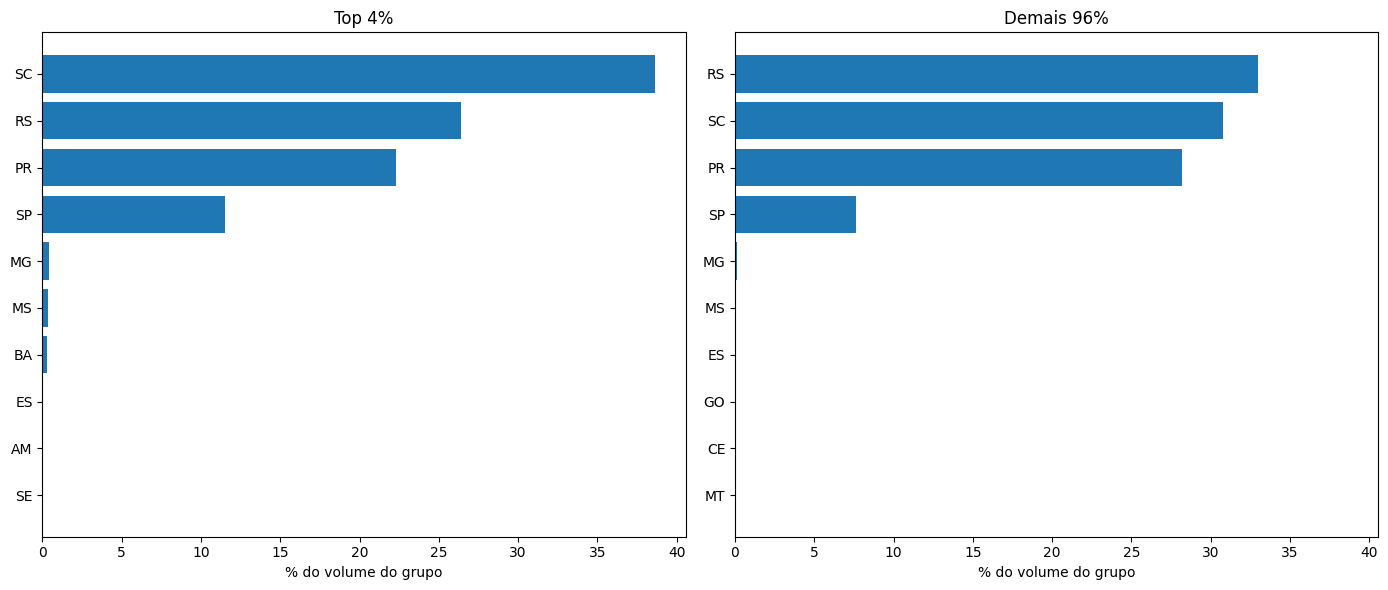

In [52]:
df_plot = (
    volume_uf_grupo
    .sort_values(["grupo_cliente", "pct_grupo"], ascending=[True, False])
    .groupby("grupo_cliente")
    .head(10)
    .copy()
)

df_plot["pct_grupo"] *= 100

df_top = df_plot[df_plot["grupo_cliente"] == "Top 4%"].sort_values("pct_grupo")
df_demais = df_plot[df_plot["grupo_cliente"] == "Demais 96%"].sort_values("pct_grupo")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

axes[0].barh(df_top["uf_sigla"], df_top["pct_grupo"])
axes[0].set_title("Top 4%")
axes[0].set_xlabel("% do volume do grupo")

axes[1].barh(df_demais["uf_sigla"], df_demais["pct_grupo"])
axes[1].set_title("Demais 96%")
axes[1].set_xlabel("% do volume do grupo")

plt.tight_layout()
plt.show()

### Checkpoint 7

#### Concentração Geográfica do Volume

Após analisar a concentração por cliente e por setor econômico (CNAE), avancei para a dimensão geográfica com o objetivo de avaliar possível dependência territorial.

#### Distribuição Geral por UF

A análise do volume total (pesom3) por UF revelou forte concentração regional:

- SC: ~37,1%
- RS: ~27,7%
- PR: ~23,5%
- SP: ~10,7%

As três principais UFs (SC, RS e PR) concentram aproximadamente 88,3% do volume total.
Com a inclusão de SP, o acumulado atinge cerca de 99%.

Isso indica uma operação fortemente concentrada na região Sul, o que já era esperado pelo foco de atuação da empresa, com participação complementar relevante de São Paulo.

#### Quantidade de UFs para atingir marcos de volume

Com base no acumulado:

- 1 UF é suficiente para atingir 25% do volume.
- 2 UFs são suficientes para ultrapassar 50%.
- 3 UFs já superam 80% do volume total.

Isso confirma alta concentração territorial.

#### Comparação Top 4% vs Demais 96%

A segmentação por grupo de cliente mostrou:

**Top 4%**
- SC: ~38%
- RS: ~27%
- PR: ~22%
- SP: ~11%

**Demais 96%**
- RS: ~33%
- SC: ~31%
- PR: ~28%
- SP: ~7,6%

Observações relevantes:

1. Ambos os grupos apresentam forte concentração na região Sul.
2. O Top 4% tem leve maior peso relativo em SC.
3. O grupo "Demais 96%" apresenta distribuição um pouco mais equilibrada entre RS e SC.
4. SP tem maior participação relativa no Top 4% do que no restante da base.

#### Interpretação

A concentração geográfica é estruturalmente alta, independentemente do grupo analisado. O risco territorial está concentrado essencialmente em três estados da região Sul.

Diferentemente da análise setorial (onde não houve dependência relevante), aqui existe clara concentração regional.

Portanto:

- O risco de concentração não é setorial.
- O risco de concentração é simultaneamente:
  - Por cliente (alta dependência de poucos embarcadores)
  - Por região (forte dependência da região Sul)

Essa estrutura sugere que qualquer choque econômico ou operacional na região Sul teria impacto significativo sobre o volume total da operação.

## Eficiência de Carga

In [53]:
comparativo_tarifacao = (
    volumetria_enriquecida
    .assign(peso_maior=lambda df: df["peso"] >= df["pesom3"])
)

comparativo_tarifacao["peso_maior"].mean()

np.float64(0.9997506305806767)

In [54]:
volumetria_enriquecida["fator_cubagem"] = (
    volumetria_enriquecida["pesom3"] / volumetria_enriquecida["m3"]
)

volumetria_enriquecida["fator_cubagem"].describe(percentiles=[.05, .5, .95])

count    2.654696e+06
mean              inf
std               NaN
min      4.347826e-03
5%       1.000000e+00
50%               NaN
95%               NaN
max               inf
Name: fator_cubagem, dtype: float64

In [55]:
volumetria_enriquecida["fator_cubagem"] = np.where(
    volumetria_enriquecida["m3"] > 0,
    volumetria_enriquecida["pesom3"] / volumetria_enriquecida["m3"],
    np.nan
)

volumetria_enriquecida["fator_cubagem"].describe(percentiles=[.05, .5, .95])

count    5.291630e+05
mean     3.688930e+02
std      1.964455e+04
min      4.347826e-03
5%       8.499396e-01
50%      1.000000e+00
95%      8.275862e+02
max      7.418000e+06
Name: fator_cubagem, dtype: float64

In [56]:
comparativo_operacional = (
    volumetria_enriquecida
    .groupby("grupo_cliente")
    .agg(
        peso_medio=("peso", "mean"),
        pesom3_medio=("pesom3", "mean"),
        m3_medio=("m3", "mean"),
        volumes_medio=("volumes", "mean"),
        ctes_medio=("qtd_ctes", "mean"),
        desconto_medio=("perc_descm3", "mean")
    )
)

comparativo_operacional

,peso_medio,pesom3_medio,m3_medio,volumes_medio,ctes_medio,desconto_medio
grupo_cliente,,,,,,
Demais 96%,35.371519,26.394523,0.097762,2.937430,1.123318,0.459864
Top 4%,141.768506,120.769901,0.212797,10.677662,1.682303,1.161466


In [57]:
volumetria_enriquecida.loc[volumetria_enriquecida["m3"] > 0, "m3"].describe(percentiles=[.01, .05, .5, .95, .99])

count    529163.000000
mean          0.759617
std           4.533680
min           0.000100
1%            0.003000
5%            0.012000
50%           0.287200
95%           2.919000
99%           7.662780
max        3030.627600
Name: m3, dtype: float64

In [58]:
mask = volumetria_enriquecida["m3"] >= 0.01
fator_filtrado = (volumetria_enriquecida.loc[mask, "pesom3"] / volumetria_enriquecida.loc[mask, "m3"])
fator_filtrado.describe(percentiles=[.05, .5, .95, .99])

count    508400.000000
mean        209.484988
std        1244.581354
min           0.004348
5%            0.849877
50%           1.000000
95%         758.333333
99%        1988.236807
max      316707.600000
dtype: float64

In [59]:
(mask.mean(), mask.sum())

(np.float64(0.1915096869848751), np.int64(508400))

In [60]:
(
    volumetria_enriquecida
    .assign(m3_zero = volumetria_enriquecida["m3"] == 0)
    .groupby("grupo_cliente")["m3_zero"]
    .mean()
)

grupo_cliente
Demais 96%    0.805947
Top 4%        0.794631
Name: m3_zero, dtype: float64

In [61]:
p99 = fator_filtrado.quantile(0.99)
fator_limpo = fator_filtrado[fator_filtrado <= p99]

fator_limpo.describe(percentiles=[.05, .5, .95])

count    503316.000000
mean        151.176771
std         269.831197
min           0.004348
5%            0.849808
50%           1.000000
95%         690.013316
max        1988.231511
dtype: float64

In [62]:
(volumetria_enriquecida["pesom3"] > volumetria_enriquecida["peso"]).mean()

np.float64(0.0002493694193233425)

In [63]:
volumetria_enriquecida[[
    "peso",
    "volumes",
    "qtd_ctes",
    "perc_descm3"
]].corr()

,peso,volumes,qtd_ctes,perc_descm3
peso,1.000000,0.495463,0.296578,0.091004
volumes,0.495463,1.000000,0.391397,0.214263
qtd_ctes,0.296578,0.391397,1.000000,0.156763
perc_descm3,0.091004,0.214263,0.156763,1.000000


In [64]:
volumetria_enriquecida["faixa_peso"] = pd.qcut(
    volumetria_enriquecida["peso"],
    q=5,
    duplicates="drop"
)

(
    volumetria_enriquecida
    .groupby("faixa_peso")["perc_descm3"]
    .mean()
)

faixa_peso
(0.0, 3.0]            0.147013
(3.0, 10.0]           0.287058
(10.0, 27.985]        0.496970
(27.985, 81.82]       0.896988
(81.82, 16495.375]    2.125569
Name: perc_descm3, dtype: float64

In [65]:
volumetria_enriquecida["faixa_volumes"] = pd.qcut(
    volumetria_enriquecida["volumes"],
    q=5,
    duplicates="drop"
)

(
    volumetria_enriquecida
    .groupby("faixa_volumes")["perc_descm3"]
    .mean()
)

faixa_volumes
(0.999, 2.0]     0.258740
(2.0, 6.0]       0.716795
(6.0, 4575.0]    2.667736
Name: perc_descm3, dtype: float64

In [66]:
(
    volumetria_enriquecida
    .groupby(["faixa_peso", "grupo_cliente"])["perc_descm3"]
    .mean()
    .unstack()
)

grupo_cliente,Demais 96%,Top 4%
faixa_peso,,
"(0.0, 3.0]",0.096708,0.271611
"(3.0, 10.0]",0.213376,0.433563
"(10.0, 27.985]",0.400484,0.616103
"(27.985, 81.82]",0.688150,1.072861
"(81.82, 16495.375]",1.790926,2.251027


In [67]:
(
    volumetria_enriquecida
    .groupby(["faixa_volumes", "grupo_cliente"])["perc_descm3"]
    .mean()
    .unstack()
)

grupo_cliente,Demais 96%,Top 4%
faixa_volumes,,
"(0.999, 2.0]",0.193218,0.382699
"(2.0, 6.0]",0.662465,0.758642
"(6.0, 4575.0]",2.617405,2.682835


In [68]:
tabela_peso = (
    volumetria_enriquecida
    .groupby(["faixa_peso", "grupo_cliente"])["perc_descm3"]
    .mean()
    .unstack()
)

tabela_peso["gap_top_vs_demais"] = (
    tabela_peso["Top 4%"] - tabela_peso["Demais 96%"]
)

tabela_peso

grupo_cliente,Demais 96%,Top 4%,gap_top_vs_demais
faixa_peso,,,
"(0.0, 3.0]",0.096708,0.271611,0.174903
"(3.0, 10.0]",0.213376,0.433563,0.220187
"(10.0, 27.985]",0.400484,0.616103,0.215619
"(27.985, 81.82]",0.688150,1.072861,0.384711
"(81.82, 16495.375]",1.790926,2.251027,0.460101


In [69]:
peso_top_por_faixa = (
    volumetria_enriquecida
    .query('grupo_cliente == "Top 4%"')
    .groupby("faixa_peso")["peso"]
    .sum()
)

peso_top_por_faixa

faixa_peso
(0.0, 3.0]            2.270264e+05
(3.0, 10.0]           1.128603e+06
(10.0, 27.985]        4.126800e+06
(27.985, 81.82]       1.430030e+07
(81.82, 16495.375]    1.557519e+08
Name: peso, dtype: float64

In [70]:
impacto = (
    peso_top_por_faixa *
    tabela_peso["gap_top_vs_demais"]
)

impacto

faixa_peso
(0.0, 3.0]            3.970764e+04
(3.0, 10.0]           2.485039e+05
(10.0, 27.985]        8.898164e+05
(27.985, 81.82]       5.501484e+06
(81.82, 16495.375]    7.166158e+07
dtype: float64

In [71]:
prop_top = (
    peso_top_por_faixa /
    peso_top_por_faixa.sum()
)

prop_top

faixa_peso
(0.0, 3.0]            0.001293
(3.0, 10.0]           0.006430
(10.0, 27.985]        0.023510
(27.985, 81.82]       0.081467
(81.82, 16495.375]    0.887300
Name: peso, dtype: float64

In [72]:
peso_demais_por_faixa = (
    volumetria_enriquecida
    .query('grupo_cliente == "Demais 96%"')
    .groupby("faixa_peso")["peso"]
    .sum()
)

prop_demais = (
    peso_demais_por_faixa /
    peso_demais_por_faixa.sum()
)

prop_demais

faixa_peso
(0.0, 3.0]            0.011076
(3.0, 10.0]           0.045037
(10.0, 27.985]        0.098843
(27.985, 81.82]       0.231440
(81.82, 16495.375]    0.613604
Name: peso, dtype: float64

In [73]:
comparativo_estrutura = (
    pd.concat([prop_top, prop_demais], axis=1)
)

comparativo_estrutura.columns = ["Top 4%", "Demais 96%"]

comparativo_estrutura

,Top 4%,Demais 96%
faixa_peso,,
"(0.0, 3.0]",0.001293,0.011076
"(3.0, 10.0]",0.006430,0.045037
"(10.0, 27.985]",0.023510,0.098843
"(27.985, 81.82]",0.081467,0.231440
"(81.82, 16495.375]",0.887300,0.613604


In [74]:
peso_top_81 = peso_top_por_faixa.iloc[-1]
peso_top_81

np.float64(155751911.8121)

In [75]:
reducao = 0.001  # 0,1 ponto percentual

impacto_simulado = peso_top_81 * reducao

impacto_simulado

np.float64(155751.9118121)

In [76]:
for r in [0.0005, 0.001, 0.002, 0.005]:
    print(f"Redução {r*100:.2f} p.p.: {peso_top_81 * r:,.0f}")

Redução 0.05 p.p.: 77,876
Redução 0.10 p.p.: 155,752
Redução 0.20 p.p.: 311,504
Redução 0.50 p.p.: 778,760


In [77]:
vol_total = volumetria_enriquecida["pesom3"].sum()

vol_por_grupo = (
    volumetria_enriquecida
    .groupby("grupo_cliente")["pesom3"]
    .sum()
)

participacao = vol_por_grupo / vol_total

participacao

grupo_cliente
Demais 96%    0.20002
Top 4%        0.79998
Name: pesom3, dtype: float64

In [78]:
top_clientes = (
    volumetria_enriquecida
    .query('grupo_cliente == "Top 4%"')
    .groupby("cli_codigo", as_index=False)
    .agg(total_pesom3=("pesom3", "sum"))
    .sort_values("total_pesom3", ascending=False)
)

top_clientes["pct_top"] = (
    top_clientes["total_pesom3"] /
    top_clientes["total_pesom3"].sum()
)

top_clientes["pct_acum_top"] = top_clientes["pct_top"].cumsum()

top_clientes.head(10)

,cli_codigo,total_pesom3,pct_top,pct_acum_top
4897,4228148,1.354973e+06,0.009061,0.009061
1064,2759536,1.338923e+06,0.008954,0.018015
4870,4226575,1.302794e+06,0.008712,0.026728
717,2674191,1.227777e+06,0.008211,0.034938
4288,4159665,1.147559e+06,0.007674,0.042612
4783,4218632,9.096163e+05,0.006083,0.048695
5009,4236731,8.568441e+05,0.005730,0.054425
4180,4135355,8.386118e+05,0.005608,0.060034
2406,3176842,8.032032e+05,0.005371,0.065405
1152,2784371,7.623047e+05,0.005098,0.070503


In [79]:
top_clientes_prop = top_clientes / top_clientes.sum()
top_clientes_acum = top_clientes_prop.cumsum()

top_clientes_acum.head(10)

,cli_codigo,total_pesom3,pct_top,pct_acum_top
4897,0.000212,0.009061,0.009061,0.000002
1064,0.00035,0.018015,0.018015,0.000006
4870,0.000561,0.026728,0.026728,0.000011
717,0.000695,0.034938,0.034938,0.000019
4288,0.000904,0.042612,0.042612,0.000028
4783,0.001115,0.048695,0.048695,0.000038
5009,0.001327,0.054425,0.054425,0.000050
4180,0.001534,0.060034,0.060034,0.000062
2406,0.001693,0.065405,0.065405,0.000076
1152,0.001832,0.070503,0.070503,0.000091


In [80]:
for thr in [0.25, 0.5, 0.8]:
    n = (top_clientes["pct_acum_top"] <= thr).sum()
    print(f"Clientes necessários para atingir {int(thr*100)}% do volume do Top 4%: {n}")

Clientes necessários para atingir 25% do volume do Top 4%: 89
Clientes necessários para atingir 50% do volume do Top 4%: 404
Clientes necessários para atingir 80% do volume do Top 4%: 1865


In [81]:
vol_total = volumetria_enriquecida["pesom3"].sum()

vol_top = (
    volumetria_enriquecida
    .query('grupo_cliente == "Top 4%"')["pesom3"]
    .sum()
)

vol_total, vol_top

(np.float64(186922951.64810002), np.float64(149534634.5783))

In [82]:
cenarios = [0.05, 0.10, 0.20]

for c in cenarios:
    perda_abs = vol_top * c
    perda_pct_empresa = perda_abs / vol_total
    print(f"Churn {int(c*100)}% do Top 4%:")
    print(f"  Perda absoluta: {perda_abs:,.0f}")
    print(f"  % do volume total da empresa: {perda_pct_empresa:.2%}")
    print("")

Churn 5% do Top 4%:
  Perda absoluta: 7,476,732
  % do volume total da empresa: 4.00%

Churn 10% do Top 4%:
  Perda absoluta: 14,953,463
  % do volume total da empresa: 8.00%

Churn 20% do Top 4%:
  Perda absoluta: 29,906,927
  % do volume total da empresa: 16.00%



In [83]:
top_81 = (
    volumetria_enriquecida
    .query('grupo_cliente == "Top 4%"')
    .query('peso > 81.82')
)

vol_top_81 = top_81["pesom3"].sum()

vol_top_81

np.float64(132307817.96720001)

In [84]:
reducao = 0.002
cenarios_churn = [0.02, 0.05, 0.10]

for churn in cenarios_churn:
    
    ganho = vol_top_81 * reducao
    perda = vol_top * churn
    impacto_liquido = ganho - perda
    
    print(f"Churn {int(churn*100)}%:")
    print(f"  Ganho com redução desconto: {ganho:,.0f}")
    print(f"  Perda por churn: {perda:,.0f}")
    print(f"  Impacto líquido: {impacto_liquido:,.0f}")
    print("")

Churn 2%:
  Ganho com redução desconto: 264,616
  Perda por churn: 2,990,693
  Impacto líquido: -2,726,077

Churn 5%:
  Ganho com redução desconto: 264,616
  Perda por churn: 7,476,732
  Impacto líquido: -7,212,116

Churn 10%:
  Ganho com redução desconto: 264,616
  Perda por churn: 14,953,463
  Impacto líquido: -14,688,848



In [85]:
churn_max = (vol_top_81 * 0.002) / vol_top
churn_max

np.float64(0.001769594292858226)

In [86]:
# premissas do cenário (mantém consistência com o que já foi calculado)
# vol_top: volume (pesom3) do Top 4%
# vol_top_81: volume (pesom3) do Top 4% na faixa 81+ kg

reducoes = np.array([0.0005, 0.001, 0.002, 0.003, 0.005])  # 0,05 a 0,50 p.p.
churns = np.array([0.0, 0.002, 0.005, 0.01, 0.02, 0.05])   # 0% a 5%

mat = []
for r in reducoes:
    ganho = vol_top_81 * r
    linha = []
    for c in churns:
        perda = vol_top * c
        linha.append(ganho - perda)  # impacto líquido
    mat.append(linha)

sens = pd.DataFrame(
    mat,
    index=[r for r in reducoes],
    columns=[c for c in churns],
)

sens

,0.000,0.002,0.005,0.010,0.020,0.050
0.0005,66153.908984,-232915.360173,-681519.263908,-1.429192e+06,-2.924539e+06,-7.410578e+06
0.0010,132307.817967,-166761.451189,-615365.354924,-1.363039e+06,-2.858385e+06,-7.344424e+06
0.0020,264615.635934,-34453.633222,-483057.536957,-1.230731e+06,-2.726077e+06,-7.212116e+06
0.0030,396923.453902,97854.184745,-350749.718990,-1.098423e+06,-2.593769e+06,-7.079808e+06
0.0050,661539.089836,362469.820679,-86134.083055,-8.338073e+05,-2.329154e+06,-6.815193e+06


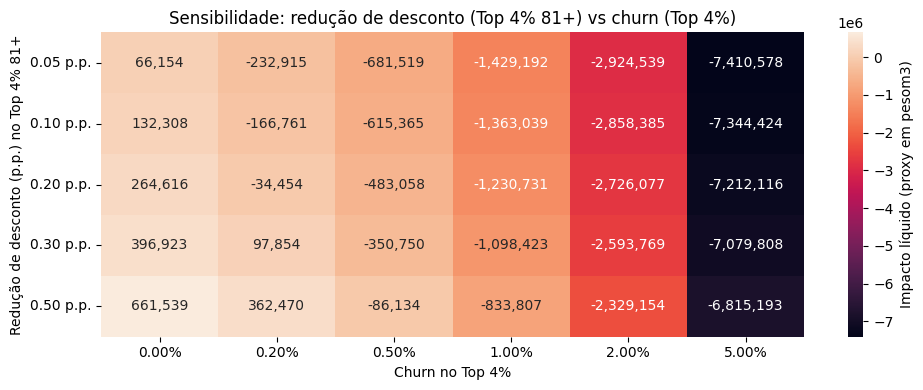

In [87]:
plt.figure(figsize=(10, 4))
sns.heatmap(
    sens,
    annot=True,
    fmt=",.0f",
    cbar_kws={"label": "Impacto líquido (proxy em pesom3)"},
)

plt.title("Sensibilidade: redução de desconto (Top 4% 81+) vs churn (Top 4%)")
plt.xlabel("Churn no Top 4%")
plt.ylabel("Redução de desconto (p.p.) no Top 4% 81+")
plt.xticks(
    ticks=np.arange(len(sens.columns)) + 0.5,
    labels=[f"{c*100:.2f}%" for c in sens.columns],
    rotation=0
)
plt.yticks(
    ticks=np.arange(len(sens.index)) + 0.5,
    labels=[f"{r*100:.2f} p.p." for r in sens.index],
    rotation=0
)
plt.tight_layout()
plt.show()

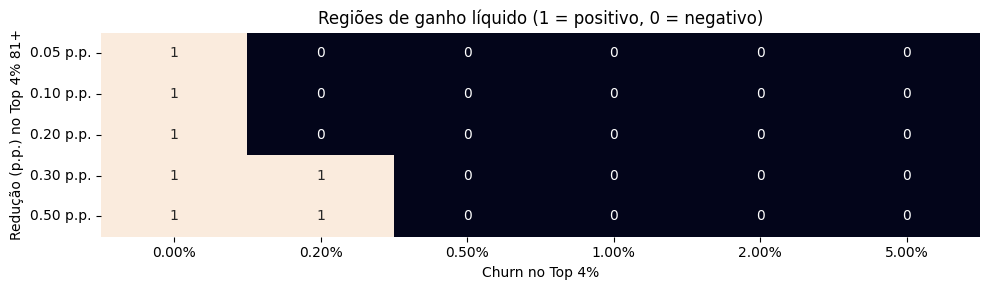

In [88]:
sens_ok = (sens > 0).astype(int)

plt.figure(figsize=(10, 3))
sns.heatmap(
    sens_ok,
    annot=True,
    fmt="d",
    cbar=False
)

plt.title("Regiões de ganho líquido (1 = positivo, 0 = negativo)")
plt.xlabel("Churn no Top 4%")
plt.ylabel("Redução (p.p.) no Top 4% 81+")
plt.xticks(
    ticks=np.arange(len(sens_ok.columns)) + 0.5,
    labels=[f"{c*100:.2f}%" for c in sens_ok.columns],
    rotation=0
)
plt.yticks(
    ticks=np.arange(len(sens_ok.index)) + 0.5,
    labels=[f"{r*100:.2f} p.p." for r in sens_ok.index],
    rotation=0
)
plt.tight_layout()
plt.show()

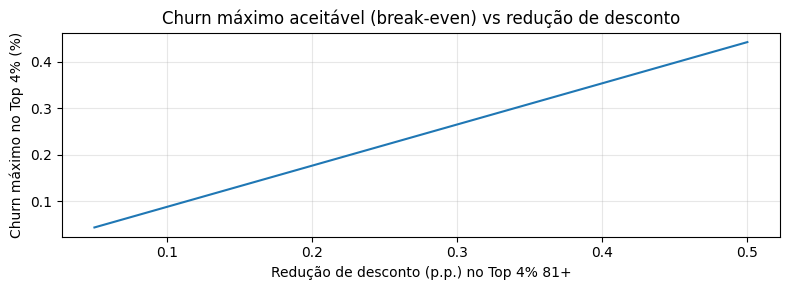

In [89]:
reducoes_lin = np.linspace(0.0005, 0.005, 50)
churn_break = (vol_top_81 * reducoes_lin) / vol_top

plt.figure(figsize=(8, 3))
plt.plot(reducoes_lin * 100, churn_break * 100)
plt.title("Churn máximo aceitável (break-even) vs redução de desconto")
plt.xlabel("Redução de desconto (p.p.) no Top 4% 81+")
plt.ylabel("Churn máximo no Top 4% (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Checkpoint 8

Nesta etapa eu saí do diagnóstico descritivo e passei a transformar os achados de “Eficiência de Carga” em hipóteses operacionais e simulações simples, com foco em decisões de negócio (principalmente precificação e risco de carteira).

O racional foi: como a Expresso São Miguel é uma empresa de logística com operação concentrada no Sul do Brasil, faz sentido investigar (i) como o volume está distribuído entre clientes e (ii) se existe espaço para capturar margem via desconto sem gerar perda relevante de volume (churn).

#### 1) Comparação entre `peso` e `pesom3` e validação da lógica de tarifação

Antes de usar `pesom3` como métrica central, eu validei a relação entre `peso` (peso físico) e `pesom3` (peso cubado/tarifário). Pela definição, `pesom3` deveria ser a base de tarifação em muitos cenários (especialmente quando há cubagem), então eu verifiquei a proporção de casos em que `peso >= pesom3` e `pesom3 > peso`.

O resultado mostrou que `pesom3 > peso` é extremamente raro (na ordem de ~0,02%), o que sugere que, para quase todos os registros, o peso tarifário não está “ganhando” do peso físico. Isso é um sinal importante: a operação parece ser majoritariamente orientada a cargas densas (onde o peso físico domina), ou a cubagem (`m3`) está frequentemente zerada/ausente.

#### 2) Fator de cubagem (`pesom3 / m3`) e impacto de `m3 == 0`

Para entender se havia um “padrão físico” razoável entre cubagem e peso tarifário, eu calculei o fator de cubagem (`fator_cubagem = pesom3 / m3`). No primeiro cálculo, apareceram `inf` e estatísticas quebradas, porque uma parcela muito grande dos registros tem `m3 == 0`. Isso contaminava diretamente a métrica, pois dividir por zero gera infinito e distorce média/percentis.

Eu tratei explicitamente esse caso definindo `fator_cubagem` como `NaN` quando `m3 == 0`, e só então reavaliei a distribuição.

Esse passo foi importante por dois motivos:
- reforçou que `m3` não pode ser usado diretamente como variável operacional sem filtro (porque está zerado na maior parte dos registros);
- permitiu medir o fator de cubagem apenas onde ele faz sentido (cubagem positiva), revelando uma distribuição extremamente assimétrica e com cauda longa (compatível com casos de baixa cubagem gerando fatores enormes).

Como refinamento adicional, eu filtrei para `m3 >= 0,01` e depois “cortei” outliers acima do p99, para evitar que poucos casos extremos dominassem a leitura. Mesmo assim, a dispersão permaneceu alta, indicando heterogeneidade de carga ou ruído de medição/registro em cubagem.

Além disso, eu comparei a taxa de `m3 == 0` por grupo de cliente (Top 4% vs Demais 96%) e vi que ambos os grupos têm proporções muito altas e semelhantes. Isso sugere que não é um problema restrito a um segmento: é uma característica estrutural da base.

#### 3) Relação entre variáveis operacionais e desconto (`perc_descm3`)

Em seguida eu olhei correlações simples entre `peso`, `volumes`, `qtd_ctes` e `perc_descm3`. A intenção aqui não foi inferir causalidade, e sim testar se existe sinal consistente de que “cargas maiores” recebem mais desconto.

As correlações foram positivas, com destaque para:
- `perc_descm3` com `volumes` (mais forte que com `peso`);
- `perc_descm3` com `qtd_ctes` (moderada);
- `perc_descm3` com `peso` (mais fraca).

Isso já deu uma pista operacional: o desconto parece reagir mais à complexidade/quantidade de volumes e CTes do que ao peso isolado.

Para deixar isso mais interpretável, eu discretizei `peso` em quintis (`qcut`) e comparei a média de `perc_descm3` por faixa. O padrão foi monotônico: faixas mais pesadas têm desconto médio maior. Fiz o mesmo com `volumes` (com menos faixas por conta de duplicidade de valores) e também observei aumento de desconto nas faixas superiores.

Depois, eu segmentei por `grupo_cliente` (Top 4% vs Demais 96%) dentro das faixas e comparei as médias. Em todas as faixas, o Top 4% tem desconto médio maior. A diferença (gap) cresce nas faixas mais altas de peso, o que é coerente com uma estratégia comercial de retenção/competitividade para grandes embarcadores.

#### 4) Priorização: onde o gap de desconto “pesa” mais

Só olhar o gap percentual não resolve o problema de priorização, porque o impacto financeiro depende do volume associado. Então eu combinei duas coisas:
- o peso total do Top 4% por faixa de peso;
- o gap de desconto do Top 4% vs Demais na mesma faixa.

A ideia foi montar um indicador de “impacto potencial” (proxy): faixas onde o Top concentra muito volume e onde o gap é maior são candidatas naturais a revisão de política comercial.

Esse exercício mostrou que a faixa mais alta (81,82+ kg) domina a estrutura do Top 4% (em proporção e em volume absoluto). Logo, se existe espaço para mexer em desconto com impacto material, ele tende a aparecer primeiro nessa faixa. Ao mesmo tempo, isso também implica risco: mexer onde há concentração maximiza impacto, mas também maximiza exposição a churn.

#### 5) Simulação de sensibilidade: redução de desconto vs churn

Com os achados acima, eu passei para um teste de hipótese mais “executivo”:

- Se eu reduzir o desconto do Top 4% (na faixa 81+), qual o ganho potencial?
- Se isso gerar churn no Top 4%, qual o tamanho da perda?
- Qual churn máximo pode ser tolerado antes do ganho ser anulado?

Eu usei `pesom3` como proxy de volume/relevância econômica para esta simulação (mantendo consistência com as análises anteriores). O desenho foi:

- Ganho = `vol_top_81 * reducao`
- Perda = `vol_top * churn`
- Impacto líquido = ganho - perda

Os resultados foram sintetizados de forma visual com:
- heatmap do impacto líquido para combinações de redução (0,05 a 0,50 p.p.) e churn (0% a 5%);
- heatmap binário indicando regiões onde o impacto é positivo/negativo;
- curva de break-even: churn máximo aceitável em função da redução.

O achado central foi que a estratégia é extremamente sensível à elasticidade:

- Para uma redução de 0,20 p.p., o churn máximo aceitável (break-even) ficou em ~0,18%.
- Mesmo churn “pequeno” (ex.: 2%) gera impacto líquido muito negativo, porque o Top 4% representa ~80% do volume total e o volume exposto à perda é enorme.

Ou seja: aumento de margem via ajuste amplo de desconto no Top 4% só faz sentido se o risco de churn for praticamente nulo. Em um contexto B2B logístico, isso sugere que ajustes devem ser cirúrgicos (por cliente/rota/segmento) e não uma regra geral.

#### Conclusão da etapa

A partir desse bloco, eu consigo sustentar três mensagens acionáveis:

1) A carteira é altamente concentrada (Top 4% responde pela maior parte do volume), então a gestão de retenção dos principais clientes é um tema central de negócio.

2) Existe evidência de que o Top 4% recebe desconto sistematicamente maior, e esse diferencial se intensifica nas faixas mais pesadas, o que sugere política comercial orientada a manter grandes embarcadores.

3) Qualquer tentativa de capturar margem via redução de desconto precisa ser cuidadosamente testada, porque o break-even de churn é muito baixo (ordem de décimos de ponto percentual). Na prática, isso aponta para otimização segmentada (onde a elasticidade é menor), e não para ajustes generalizados.

## Geografia e Dependência Regional

In [90]:
vol_geo = (
    volumetria_enriquecida
    .merge(
        cliente[["cli_codigo", "uf_sigla"]],
        on="cli_codigo",
        how="left"
    )
)

In [91]:
vol_geo["uf_sigla"].isna().mean()

np.float64(0.0)

In [92]:
uf_volume = (
    vol_geo
    .groupby("uf_sigla", as_index=False)
    .agg(total_pesom3=("pesom3", "sum"))
    .sort_values("total_pesom3", ascending=False)
)

uf_volume["pct_total"] = (
    uf_volume["total_pesom3"] /
    uf_volume["total_pesom3"].sum()
)

uf_volume["pct_acum"] = uf_volume["pct_total"].cumsum()

uf_volume

,uf_sigla,total_pesom3,pct_total,pct_acum
21,SC,6.928633e+07,3.706679e-01,0.370668
20,RS,5.180375e+07,2.771396e-01,0.647807
15,PR,4.389733e+07,2.348419e-01,0.882649
23,SP,2.007191e+07,1.073807e-01,0.990030
8,MG,6.707847e+05,3.588562e-03,0.993618
9,MS,5.719217e+05,3.059665e-03,0.996678
2,BA,4.018158e+05,2.149633e-03,0.998828
5,ES,8.159027e+04,4.364915e-04,0.999264
1,AM,4.810889e+04,2.573729e-04,0.999522
22,SE,1.945551e+04,1.040830e-04,0.999626


In [93]:
uf_grupo = (
    vol_geo
    .groupby(["uf_sigla", "grupo_cliente"], as_index=False)
    .agg(total_pesom3=("pesom3", "sum"))
)

uf_grupo["pct_dentro_uf"] = (
    uf_grupo["total_pesom3"] /
    uf_grupo.groupby("uf_sigla")["total_pesom3"].transform("sum")
)

uf_grupo.sort_values(["uf_sigla", "grupo_cliente"])

,uf_sigla,grupo_cliente,total_pesom3,pct_dentro_uf
0,AL,Demais 96%,8.560000e+01,1.000000
1,AM,Demais 96%,1.232784e+03,0.025625
2,AM,Top 4%,4.687611e+04,0.974375
3,BA,Demais 96%,6.115596e+03,0.015220
4,BA,Top 4%,3.957002e+05,0.984780
5,CE,Demais 96%,7.873927e+03,1.000000
6,DF,Demais 96%,1.635780e+03,0.140024
7,DF,Top 4%,1.004636e+04,0.859976
8,ES,Demais 96%,1.377145e+04,0.168788
9,ES,Top 4%,6.781882e+04,0.831212


In [94]:
uf_desc = (
    vol_geo
    .groupby(["uf_sigla", "grupo_cliente"], as_index=False)
    .agg(desc_medio=("perc_descm3", "mean"))
)

uf_desc_pivot = (
    uf_desc
    .pivot(index="uf_sigla", columns="grupo_cliente", values="desc_medio")
)

uf_desc_pivot["gap_top_vs_demais"] = (
    uf_desc_pivot["Top 4%"] -
    uf_desc_pivot["Demais 96%"]
)

uf_desc_pivot.sort_values("gap_top_vs_demais", ascending=False)

grupo_cliente,Demais 96%,Top 4%,gap_top_vs_demais
uf_sigla,,,
AM,0.000000,1.984111,1.984111
SP,0.284035,1.522521,1.238486
SC,0.683723,1.676897,0.993174
SE,0.000000,0.882353,0.882353
RS,0.271045,0.723864,0.452819
PR,0.467736,0.795809,0.328073
PE,0.000000,0.000000,0.000000
RJ,0.000000,0.000000,0.000000
DF,0.000000,0.000000,0.000000


In [95]:
top_por_uf_cliente = (
    vol_geo
    .query('grupo_cliente == "Top 4%"')
    .groupby(["uf_sigla", "cli_codigo"], as_index=False)
    .agg(total_pesom3=("pesom3", "sum"))
)

top_por_uf_cliente["pct_uf"] = (
    top_por_uf_cliente["total_pesom3"] /
    top_por_uf_cliente.groupby("uf_sigla")["total_pesom3"].transform("sum")
)

top_por_uf_cliente = (
    top_por_uf_cliente
    .sort_values(["uf_sigla", "total_pesom3"], ascending=[True, False])
)

top_por_uf_cliente["pct_acum"] = (
    top_por_uf_cliente
    .groupby("uf_sigla")["pct_uf"]
    .cumsum()
)

top_por_uf_cliente.head()

,uf_sigla,cli_codigo,total_pesom3,pct_uf,pct_acum
3,AM,3160582,21134.0000,0.450848,0.450848
0,AM,2840002,12905.2738,0.275306,0.726154
1,AM,2876649,7078.5100,0.151005,0.877159
2,AM,2966802,5758.3256,0.122841,1.000000
9,BA,2887510,265109.8904,0.669977,0.669977


In [96]:
concentracao_uf = (
    top_por_uf_cliente
    .groupby("uf_sigla")
    .apply(lambda df: (df["pct_acum"] <= 0.5).sum())
    .reset_index(name="clientes_50pct_top")
    .sort_values("clientes_50pct_top")
)

concentracao_uf

,uf_sigla,clientes_50pct_top
1,BA,0
2,DF,0
6,PE,0
4,MG,0
11,SE,0
8,RJ,0
3,ES,1
0,AM,1
5,MS,1
12,SP,38


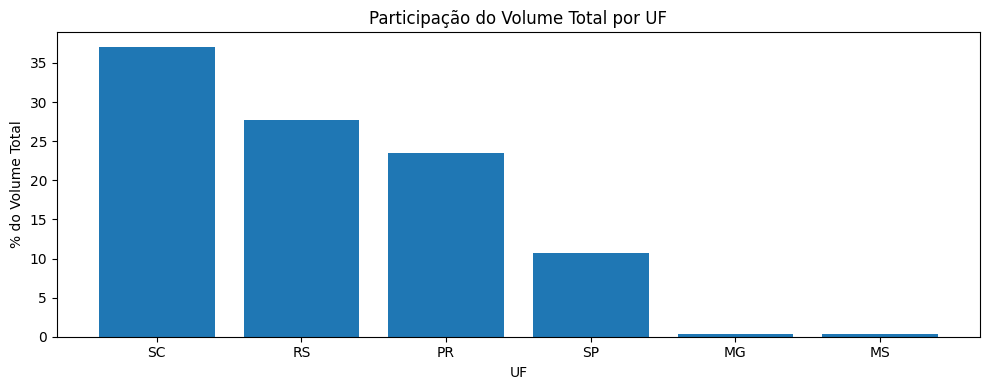

In [97]:
plt.figure(figsize=(10,4))

uf_volume_plot = uf_volume.sort_values("pct_total", ascending=False).head(6)

plt.bar(uf_volume_plot["uf_sigla"], uf_volume_plot["pct_total"] * 100)
plt.title("Participação do Volume Total por UF")
plt.ylabel("% do Volume Total")
plt.xlabel("UF")
plt.tight_layout()
plt.show()

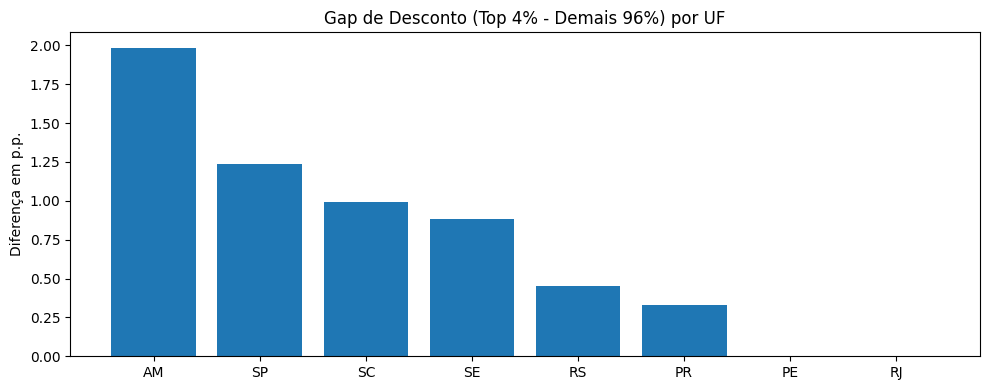

In [98]:
gap_plot = (
    uf_desc_pivot
    .sort_values("gap_top_vs_demais", ascending=False)
    .head(8)
)

plt.figure(figsize=(10,4))
plt.bar(gap_plot.index, gap_plot["gap_top_vs_demais"])
plt.title("Gap de Desconto (Top 4% - Demais 96%) por UF")
plt.ylabel("Diferença em p.p.")
plt.tight_layout()
plt.show()

### Checkpoint 9

#### Objetivo do bloco

Avaliar:

1. Concentração geográfica do volume
2. Dependência regional do Top 4%
3. Assimetria comercial (gap de desconto) por UF
4. Risco estrutural regional para a Expresso São Miguel



#### 1. Concentração de Volume por UF

Foi calculado:

- `total_pesom3` por `uf_sigla`
- `% do volume total`
- `% acumulado`

##### Resultado principal

SC, RS e PR concentram aproximadamente 88% do volume total.

Distribuição observada:

- SC ≈ 37%
- RS ≈ 28%
- PR ≈ 23%
- SP ≈ 10%
- Demais UFs: residuais

##### Interpretação

A operação é estruturalmente concentrada na região Sul, o que é coerente com o posicionamento da empresa.

Implica:

- Forte eficiência regional
- Baixa diversificação geográfica
- Risco elevado caso haja choque econômico local



#### 2. Dependência do Top 4% por UF

Foi calculado:

- Percentual do volume de cada UF que vem do Top 4%
- Pivot por `uf_sigla` × `grupo_cliente`

##### Observações

Algumas UFs apresentam forte dependência do Top 4%, enquanto outras praticamente não possuem presença desse grupo.

Estados com maior dependência relativa do Top 4%:

- AM
- SP
- SC
- SE
- RS
- PR

Interpretação crítica:

Nem todo estado relevante em volume é igualmente dependente do Top 4%.

Exemplo:
- SC é grande em volume total e relevante no Top
- AM tem baixo volume absoluto, mas alto gap de desconto

Isso diferencia risco absoluto de risco relativo.



#### 3. Gap de Desconto por UF

Foi calculado: gap_top_vs_demais = desconto_medio_top - desconto_medio_demais


##### Resultados relevantes

Maiores gaps positivos:

- AM (~2 p.p.)
- SP (~1.2 p.p.)
- SC (~1 p.p.)
- SE (~0.9 p.p.)

Estados com gap pequeno ou negativo:
- PR
- RS
- MG
- BA
- ES

##### Interpretação

Em alguns estados, o Top 4% recebe prêmio comercial relevante.

Isso pode indicar:

- Maior poder de barganha
- Maior competição local
- Estratégia comercial diferenciada por região

Estados com alto gap + alto volume são prioridade estratégica.



#### 4. Concentração de clientes Top por UF

Foi medido:

Quantidade de clientes necessários para atingir 50% do volume do Top 4% dentro de cada UF.

Resultado observado:

Alta concentração nos estados do Sul:

- RS
- SC
- PR
- SP

Interpretação:

O risco do Top 4% é também regionalmente concentrado.
Não é apenas um risco nacional, mas regional.



#### 5. Conclusões Estratégicas do Bloco

1. A empresa é altamente concentrada no Sul.
2. O Top 4% é determinante na estrutura regional.
3. Existem UFs onde o Top recebe prêmio comercial relevante.
4. O risco de churn não é homogêneo entre estados.
5. Estados grandes com alto gap merecem análise comercial prioritária.

## Estrutura Operacional e Complexidade Logística

In [99]:
volumetria_enriquecida["ctes_por_ton"] = (
    volumetria_enriquecida["qtd_ctes"] /
    (volumetria_enriquecida["peso"] / 1000)
)

(
    volumetria_enriquecida
    .groupby("grupo_cliente")["ctes_por_ton"]
    .mean()
)

grupo_cliente
Demais 96%    1073.534970
Top 4%         504.780563
Name: ctes_por_ton, dtype: float64

In [100]:
volumetria_enriquecida["volumes_por_cte"] = (
    volumetria_enriquecida["volumes"] /
    volumetria_enriquecida["qtd_ctes"]
)

(
    volumetria_enriquecida
    .groupby("grupo_cliente")["volumes_por_cte"]
    .mean()
)

grupo_cliente
Demais 96%    2.646277
Top 4%        6.400784
Name: volumes_por_cte, dtype: float64

In [101]:
(
    volumetria_enriquecida
    .groupby(["grupo_cliente", "tipopesocubico"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

grupo_cliente  grupo_cliente  tipopesocubico
Demais 96%     Demais 96%     M                 0.097133
                              P                 0.902867
Top 4%         Top 4%         M                 0.121714
                              P                 0.878286
dtype: float64

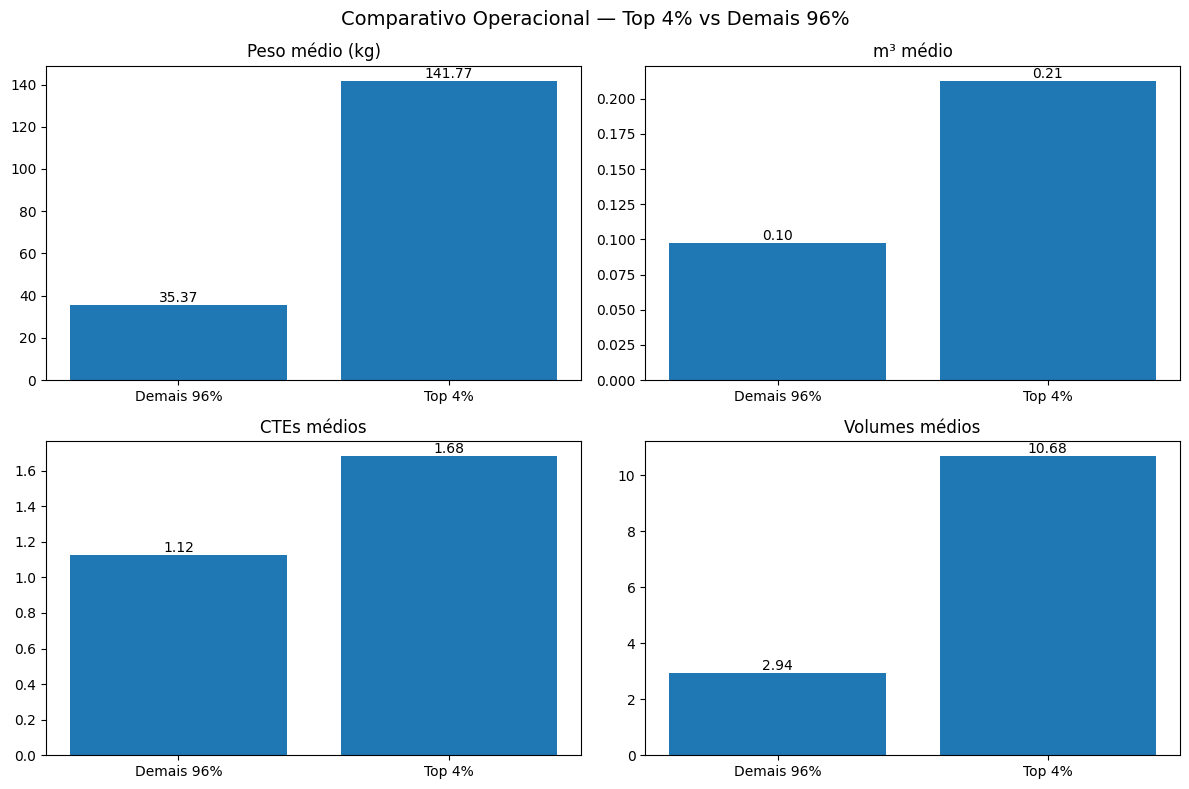

In [102]:
operacional_plot = (
    volumetria_enriquecida
    .groupby("grupo_cliente")
    .agg(
        peso_medio=("peso","mean"),
        m3_medio=("m3","mean"),
        ctes_medio=("qtd_ctes","mean"),
        volumes_medio=("volumes","mean")
    )
)

fig, axes = plt.subplots(2, 2, figsize=(12,8))

metricas = [
    ("peso_medio", "Peso médio (kg)"),
    ("m3_medio", "m³ médio"),
    ("ctes_medio", "CTEs médios"),
    ("volumes_medio", "Volumes médios")
]

for ax, (col, titulo) in zip(axes.flatten(), metricas):
    bars = ax.bar(operacional_plot.index, operacional_plot[col])
    ax.set_title(titulo)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:,.2f}",
            ha="center",
            va="bottom"
        )

plt.suptitle("Comparativo Operacional — Top 4% vs Demais 96%", fontsize=14)
plt.xlabel("")
plt.tight_layout()
plt.show()

### Checkpoint 10

#### Objetivo do bloco

Avaliar se o Top 4% possui perfil operacional diferente dos Demais 96%, com foco em:

- Peso médio por envio
- Cubagem média (m³)
- CTEs médios
- Volumes médios
- Intensidade operacional (CTEs por tonelada)
- Fragmentação (volumes por CTE)

A pergunta estratégica central:

O desconto concedido ao Top 4% está associado a maior custo operacional?



#### 1. Comparativo estrutural por envio

Métricas médias observadas:

##### Peso médio

- Demais 96% ≈ 35 kg
- Top 4% ≈ 142 kg

Top 4% movimenta cargas ~4x mais pesadas por envio.



##### m³ médio

- Demais 96% ≈ 0.10 m³
- Top 4% ≈ 0.21 m³

O Top movimenta aproximadamente o dobro de cubagem por envio.



##### CTEs médios

- Demais 96% ≈ 1.12
- Top 4% ≈ 1.68

Top emite mais documentos por envio.



##### Volumes médios

- Demais 96% ≈ 2.9 volumes
- Top 4% ≈ 10.7 volumes

Top apresenta fragmentação significativamente maior.



#### 2. Intensidade Operacional

##### CTEs por tonelada

- Demais 96% ≈ 1.073
- Top 4% ≈ 505

Interpretação:

O Top movimenta muito mais peso por documento.
Isso sugere maior consolidação por operação.



##### Volumes por CTE

- Demais 96% ≈ 2.64
- Top 4% ≈ 6.40

Top tem mais volumes por CTE.
Isso indica maior complexidade física (manuseio).



#### 3. Interpretação Estratégica

O Top 4% apresenta simultaneamente:

- Maior peso por envio
- Maior cubagem
- Mais volumes
- Mais CTEs médios
- Melhor consolidação por tonelada

Isso revela um perfil operacional híbrido:

1. Escala elevada (eficiência de consolidação)
2. Maior complexidade física (fragmentação)

Portanto:

O desconto concedido ao Top 4% não é apenas comercial.
Ele está associado a maior intensidade operacional.



#### 4. Implicações para o negócio

1. Redução de desconto pode impactar clientes estruturalmente relevantes.
2. Esses clientes ocupam maior capacidade operacional.
3. Eventual churn teria impacto logístico relevante.
4. Política comercial deve considerar custo operacional real.



#### Conclusão do bloco

O Top 4% não é apenas concentrador de receita.

Ele é estruturalmente relevante para a eficiência operacional da malha.

Qualquer decisão comercial sobre esse grupo deve considerar:

- Impacto financeiro
- Impacto operacional
- Impacto na ocupação da rede

# Diagnóstico Executivo e Recomendações Estratégicas

## Contexto do projeto

Este projeto analisa dados operacionais da Expresso São Miguel (logística na região Sul do Brasil), com foco em extrair insights acionáveis a partir de três bases:

- `volumetria`: registros operacionais por viagem (peso, cubagem, volumes, CTEs, desconto, tipo de tarifação)
- `cliente`: cadastro básico do cliente (UF, município, tipo pessoa, razão social)
- `cliente_cnae`: CNAE(s) associado(s) ao cliente, com indicação de principal

O objetivo foi entender padrões de operação, concentração de volume, diferenças estruturais entre grupos de clientes e implicações comerciais/operacionais do desconto aplicado.


## Principais achados consolidados

### 1) Concentração extrema de volume por cliente

Foi observado comportamento fortemente concentrado:

- ~4% dos clientes geram ~80% do volume (proxy em `pesom3`)

Isso caracteriza um cenário clássico de dependência de poucos clientes (risco de concentração), com impacto direto em estabilidade de receita e ocupação operacional.

Implicação:
- qualquer decisão comercial sobre a “cauda curta” tem efeito desproporcional no negócio


### 2) Padrões temporais operacionais consistentes (dia e hora)

#### Por dia da semana
A operação é tipicamente “de dias úteis”:

- picos entre terça e quinta, com destaque para quarta
- queda forte em fim de semana, principalmente domingo

Implicação:
- capacidade e escala operacional parecem dimensionadas para dias úteis
- existe potencial de ações para suavizar demanda ou elevar ocupação em janelas ociosas (fim de semana / horários específicos), se houver viabilidade comercial

#### Por hora do dia (com distribuição e heatmap)
A distribuição horária mostrou padrões claros e recorrentes, inclusive com diferenças por dia:

- concentração em faixas específicas (manhã cedo e noite)
- finais de semana com comportamento distinto (especialmente domingo)

Implicação:
- planejamento de pátio, docas e recursos pode ser alinhado a janelas de pico
- oportunidades de ajuste de SLA/agenda (quando aplicável) podem reduzir gargalos


### 3) Desconto e tarifação: comportamento consistente com regra operacional

Foi verificado que `pesom3` (peso cubado/tarifário) tende a ser maior ou igual ao peso real quase sempre, como esperado:

- em praticamente todos os registros, `pesom3 >= peso`

Além disso, a análise de `fator_cubagem = pesom3 / m3` mostrou:

- mediana próxima de 1.0, mas com cauda longa e outliers extremos
- grande volume de registros com `m3 = 0` (~80%), o que impede uso direto do fator sem filtragem

Implicação:
- `m3` não é um driver confiável universalmente (muitos zeros)
- `pesom3` é a métrica mais robusta para representar “capacidade cobrada/ocupada” na base


### 4) Top 4% vs Demais 96%: diferenças operacionais claras

O Top 4% é estruturalmente diferente do restante:

- peso médio por envio muito maior
- cubagem média maior
- volumes médios muito maiores (fragmentação)
- CTEs médios maiores

E, ao mesmo tempo:

- CTEs por tonelada menores (mais consolidação por documento)

Interpretação:
- Top 4% combina escala (mais peso/cubagem) com maior complexidade física (muitos volumes)
- não é apenas um grupo “que gera receita”; é um grupo com impacto real na operação

Implicação:
- desconto no Top 4% não deve ser analisado só como “perda comercial” ou “alavanca de preço”
- existe trade-off entre eficiência (escala) e custo operacional (manuseio)


### 5) CNAE: diversidade relevante dentro do Top 4%

Ao decompor por CNAE no Top 4%:

- é preciso um conjunto relativamente grande de CNAEs para cobrir frações altas do volume (ex.: dezenas para 50%, quase 100 para 80%)

Interpretação:
- a concentração de volume é por cliente, mas não necessariamente por um único setor
- o mix setorial do Top 4% é mais diversificado do que parece à primeira vista

Implicação:
- iniciativas comerciais devem ser mais “account-based” do que “setor-based”
- mas CNAE ajuda a orientar hipóteses de perfil de carga e sazonalidade


### 6) Geografia e dependência regional: concentração forte no Sul

A participação do volume total por UF mostrou concentração:

- SC, RS e PR respondem pela maior parte do volume (com SP como quarto polo relevante)

Além disso, ao comparar desconto (Top 4% - Demais 96%) por UF:

- algumas UFs exibem gap maior de desconto
- outras têm valores próximos de zero ou inconsistentes por baixa amostra

Implicação:
- a dependência regional é coerente com o escopo da empresa (Sul), mas também explicita risco de concentração geográfica
- gap de desconto por UF pode indicar estratégia comercial diferenciada ou composição distinta do mix de clientes


## Simulações e decisões: sensibilidade entre desconto e churn

Foi construída uma simulação para quantificar o trade-off:

- redução de desconto no Top 4% (com foco em cargas “pesadas”, faixa 81+)
versus
- churn percentual do Top 4%

Os resultados mostraram que:

- pequenas reduções de desconto geram ganho limitado
- churn mesmo baixo rapidamente supera esse ganho (impacto líquido negativo em quase todos os cenários realistas)

Interpretação executiva:
- para “pagar” uma redução de desconto pequena, o churn aceitável precisa ser muito baixo
- a elasticidade implícita (risco de churn) domina o resultado

Implicação:
- política de reajuste deve ser cirúrgica e orientada por risco
- decisões generalistas no Top 4% tendem a piorar o resultado líquido


## Recomendações acionáveis

### A) Estratégia comercial (Top 4%)

1. Evitar reajustes horizontais no Top 4%
   - a simulação indica que o risco de churn domina o ganho

2. Priorizar negociação por clusters operacionais
   - segmentar Top 4% por estrutura (peso/CTE, volumes/CTE, cubagem)
   - atacar onde há “alto volume + alta complexidade + alto desconto”

3. Criar política de desconto baseada em perfil de carga
   - ex.: maior desconto para cargas consolidadas (boa relação peso/CTE)
   - menor desconto (ou taxa operacional) para alta fragmentação (volumes/CTE alto)


### B) Eficiência operacional

4. Tratar `m3 = 0` como problema de qualidade de dado / processo
   - pode ser falha de preenchimento, integração ou regra operacional
   - recomendação: mapear origem e corrigir upstream

5. Criar indicadores recorrentes de complexidade
   - `volumes_por_cte`
   - `ctes_por_ton`
   - `peso_por_cte`
   - esses indicadores são bons candidatos a KPIs para custo operacional


### C) Planejamento de capacidade (temporal)

6. Usar o padrão dia/hora como base para dimensionamento
   - alocação de recursos e janelas críticas de operação
   - analisar se picos são “demanda real” ou “agenda operacional”

7. Explorar oportunidade de suavização (quando aplicável)
   - incentivos para janelas de menor ocupação
   - acordos comerciais por faixa horária/dia


### D) Geografia e risco regional

8. Consolidar estratégia para os três polos principais (SC/RS/PR)
   - tratar como “regiões core”
   - mapear dependência por contas-chave em cada UF

9. Investigar UFs com gap alto de desconto e baixa participação
   - risco de distorção por pouca amostra
   - ou indício de política comercial específica (vale aprofundar)


## Próximos passos recomendados (encerramento prático)

Se eu tivesse mais um ciclo curto de trabalho, priorizaria:

1. Qualidade de dado de `m3`:
   - entender por que ~80% é zero
   - checar por `tipopesocubico` / cliente / UF / data

2. Modelo simples de propensão a churn:
   - clientes do Top 4% com desconto alto vs estrutura operacional
   - priorização de contas para retenção (sem precisar dado externo)

3. Validação com área comercial/operacional:
   - confirmar se padrões temporais refletem agenda interna
   - confirmar hipóteses de complexidade por volumes


## Encerramento

Os dados mostram que a Expresso São Miguel opera com forte concentração de volume em poucos clientes, em uma malha regionalmente concentrada no Sul, e com padrões temporais consistentes.

O Top 4% é crítico não só financeiramente, mas também por ocupação e estrutura operacional. A recomendação principal é tratar a gestão de desconto e retenção como problema de risco (sensibilidade a churn), e não como simples ajuste de preço.

A partir daqui, o caminho mais seguro é:
- segmentar contas por perfil operacional
- calibrar política de desconto por custo/complexidade
- evitar ações generalistas que aumentem churn no grupo concentrador